## Overview

This notebook provides a comprehensive demonstration of several baseline algorithms used in First-Price Auction (FPA) and VCG (Vickrey–Clarke–Groves) auction scenarios. We showcase both individual performances and comparative analyses of the following algorithms:

1. ALM
2. TA-PID
3. M-PID
4. Mystique
5. BROI

## Purpose

The main objectives of this notebook are:

1. To illustrate the implementation and behavior of each baseline algorithm
2. To compare the performance of these algorithms

Feel free to add your own bidding algorithms to our benchmark 😊


# Baselines comparison

In [1]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2
    
import pandas as pd
import numpy as np
import optuna
import pickle
import matplotlib.pyplot as plt

from functools import partial

from simulator.simulation.modules import Campaign
from simulator.simulation.utils_visualization import data_prep_vis, plot_history_article
from simulator.simulation.simulate import simulate_campaign
from simulator.validation.check_results import autobidder_check

# import baselines:
from simulator.model.linear_bidder import LinearBidder
from simulator.model.ta_pid import TAPIDBidder
from simulator.model.m_pid import MPIDBidder
from simulator.model.mystique import Mystique
from simulator.model.broi_bidder import BROI
from simulator.model.traffic import Traffic
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', None)

# Load data

In [2]:
auction_mode = 'FPA' # you may also choose the 'VCG' mode

# data paths
campaigns_path = f"../../data/{auction_mode.lower()}/campaigns_{auction_mode.lower()}_filtered_train_final.csv"
stats_path = f"../../data/{auction_mode.lower()}/stats_{auction_mode.lower()}_filtered_train_final.csv"

In [3]:
campaign_df = pd.read_csv(campaigns_path)
stats_df = pd.read_csv(stats_path)

In [4]:
campaign_df.sample(1)

,Unnamed: 0,campaign_id,loc_id,item_id,campaign_start_date,campaign_start,campaign_end,auction_budget,microcat_ext,logical_category,region_id,campaign_end_date
759,6242,74251242,652000,4048836000,1986-10-14,529653142,529739542,345.6,86470,3.17,651110,1986-10-15


In [5]:
stats_df.sample(3)

,Unnamed: 0,campaign_id,period,item_id,contact_price_bin,AuctionVisibilitySurplus,AuctionClicksSurplus,AuctionContactsSurplus,AuctionWinBidSurplus,CTRPredicts,CRPredicts,AuctionCount,x_platfrom_num,platform_p
639861,1393044,74248819,529830000,3920162100,-1.0,0.857521,0.267734,0.038430,0.06,0.100324,0.166772,2,21.0,[0.2381 0.0952 0.5238 0.1429]
1223222,5177291,74113857,529758000,1337464800,6.0,1.000000,0.301202,0.012447,0.25,0.095876,0.047761,1,17.0,[0.0588 0. 0.5294 0.4118]
1457430,8217955,73797969,529610400,4274047300,47.0,5.532928,0.259085,0.027227,394.31,0.014758,0.121453,55,NaN,NaN


# One campaign's example

In [47]:
campaign_data = campaign_df.sample(1).iloc[0]
campaign_stats = stats_df[stats_df.campaign_id == campaign_data["campaign_id"]].copy()
print(campaign_data.shape, campaign_stats.shape)

(12,) (762, 14)


## Linear Bidder

In [48]:
campaign_example = Campaign(
    item_id= campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  2183.04
Length hours  24


In [49]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=LinearBidder(),
    stats_file=campaign_stats,
    auction_mode=auction_mode
)

In [50]:
df = simulation_history.to_data_frame()
viz_data_linear = data_prep_vis(df)
df.head(2)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-14 12:00:00,529664400,529663548,529749948,73593927,2136.134357,2183.04,1.394902,0.071621,654.912000,637640,637640,5.26,2278188,529660800,0,0,46.905643,1.394902,0.013186,0.013186,35.566287,33.626485
1,1986-10-14 13:00:00,529668000,529663548,529749948,73593927,1508.253134,2183.04,15.136044,0.708051,986.568649,637640,637640,5.26,2278188,529664400,0,0,627.881224,13.741142,0.013388,0.026574,37.813592,45.693524


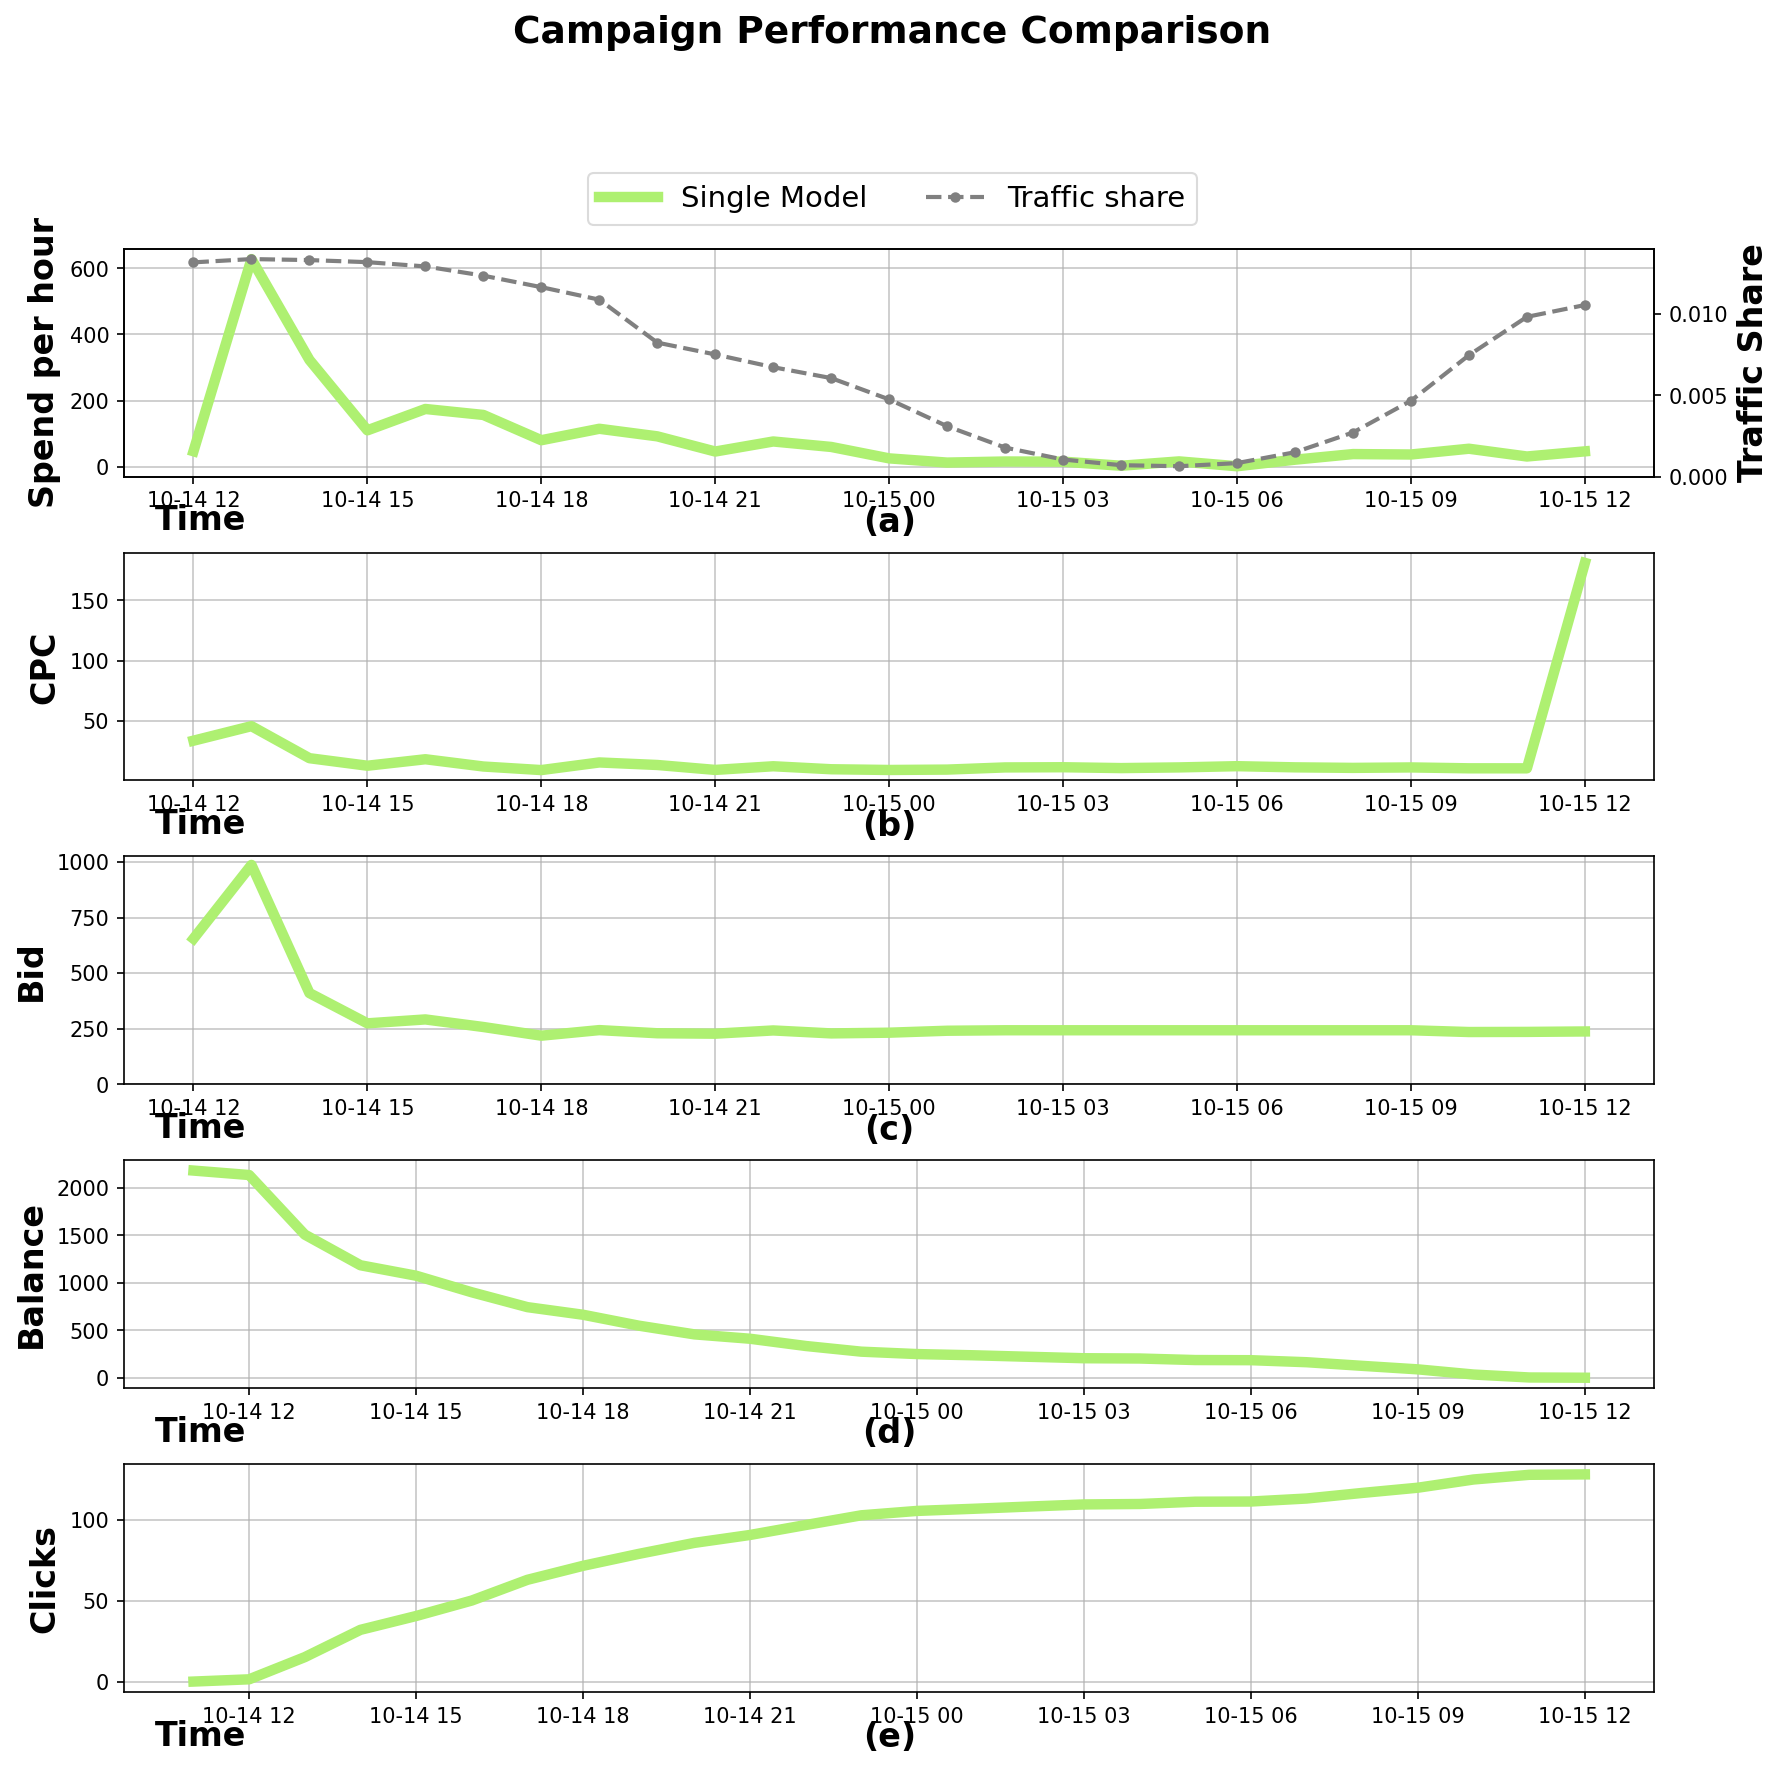

In [51]:
fig = plot_history_article(viz_data_linear)

### BROI

In [52]:
campaign_example = Campaign(
    item_id= campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  2183.04
Length hours  24


In [53]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=BROI(),
    stats_file=campaign_stats,
    auction_mode=auction_mode
)

In [54]:
df = simulation_history.to_data_frame()
viz_data_broi = data_prep_vis(df)
df.head(2)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-14 12:00:00,529664400,529663548,529749948,73593927,2182.886735,2183.04,0.482095,0.024753,6.191736,637640,637640,5.26,2278188,529660800,0,0,0.153265,0.482095,0.013186,0.013186,10.0,0.317915
1,1986-10-14 13:00:00,529668000,529663548,529749948,73593927,2180.674010,2183.04,8.622256,0.382121,6.191736,637640,637640,5.26,2278188,529664400,0,0,2.212724,8.140160,0.013388,0.026574,10.0,0.271828


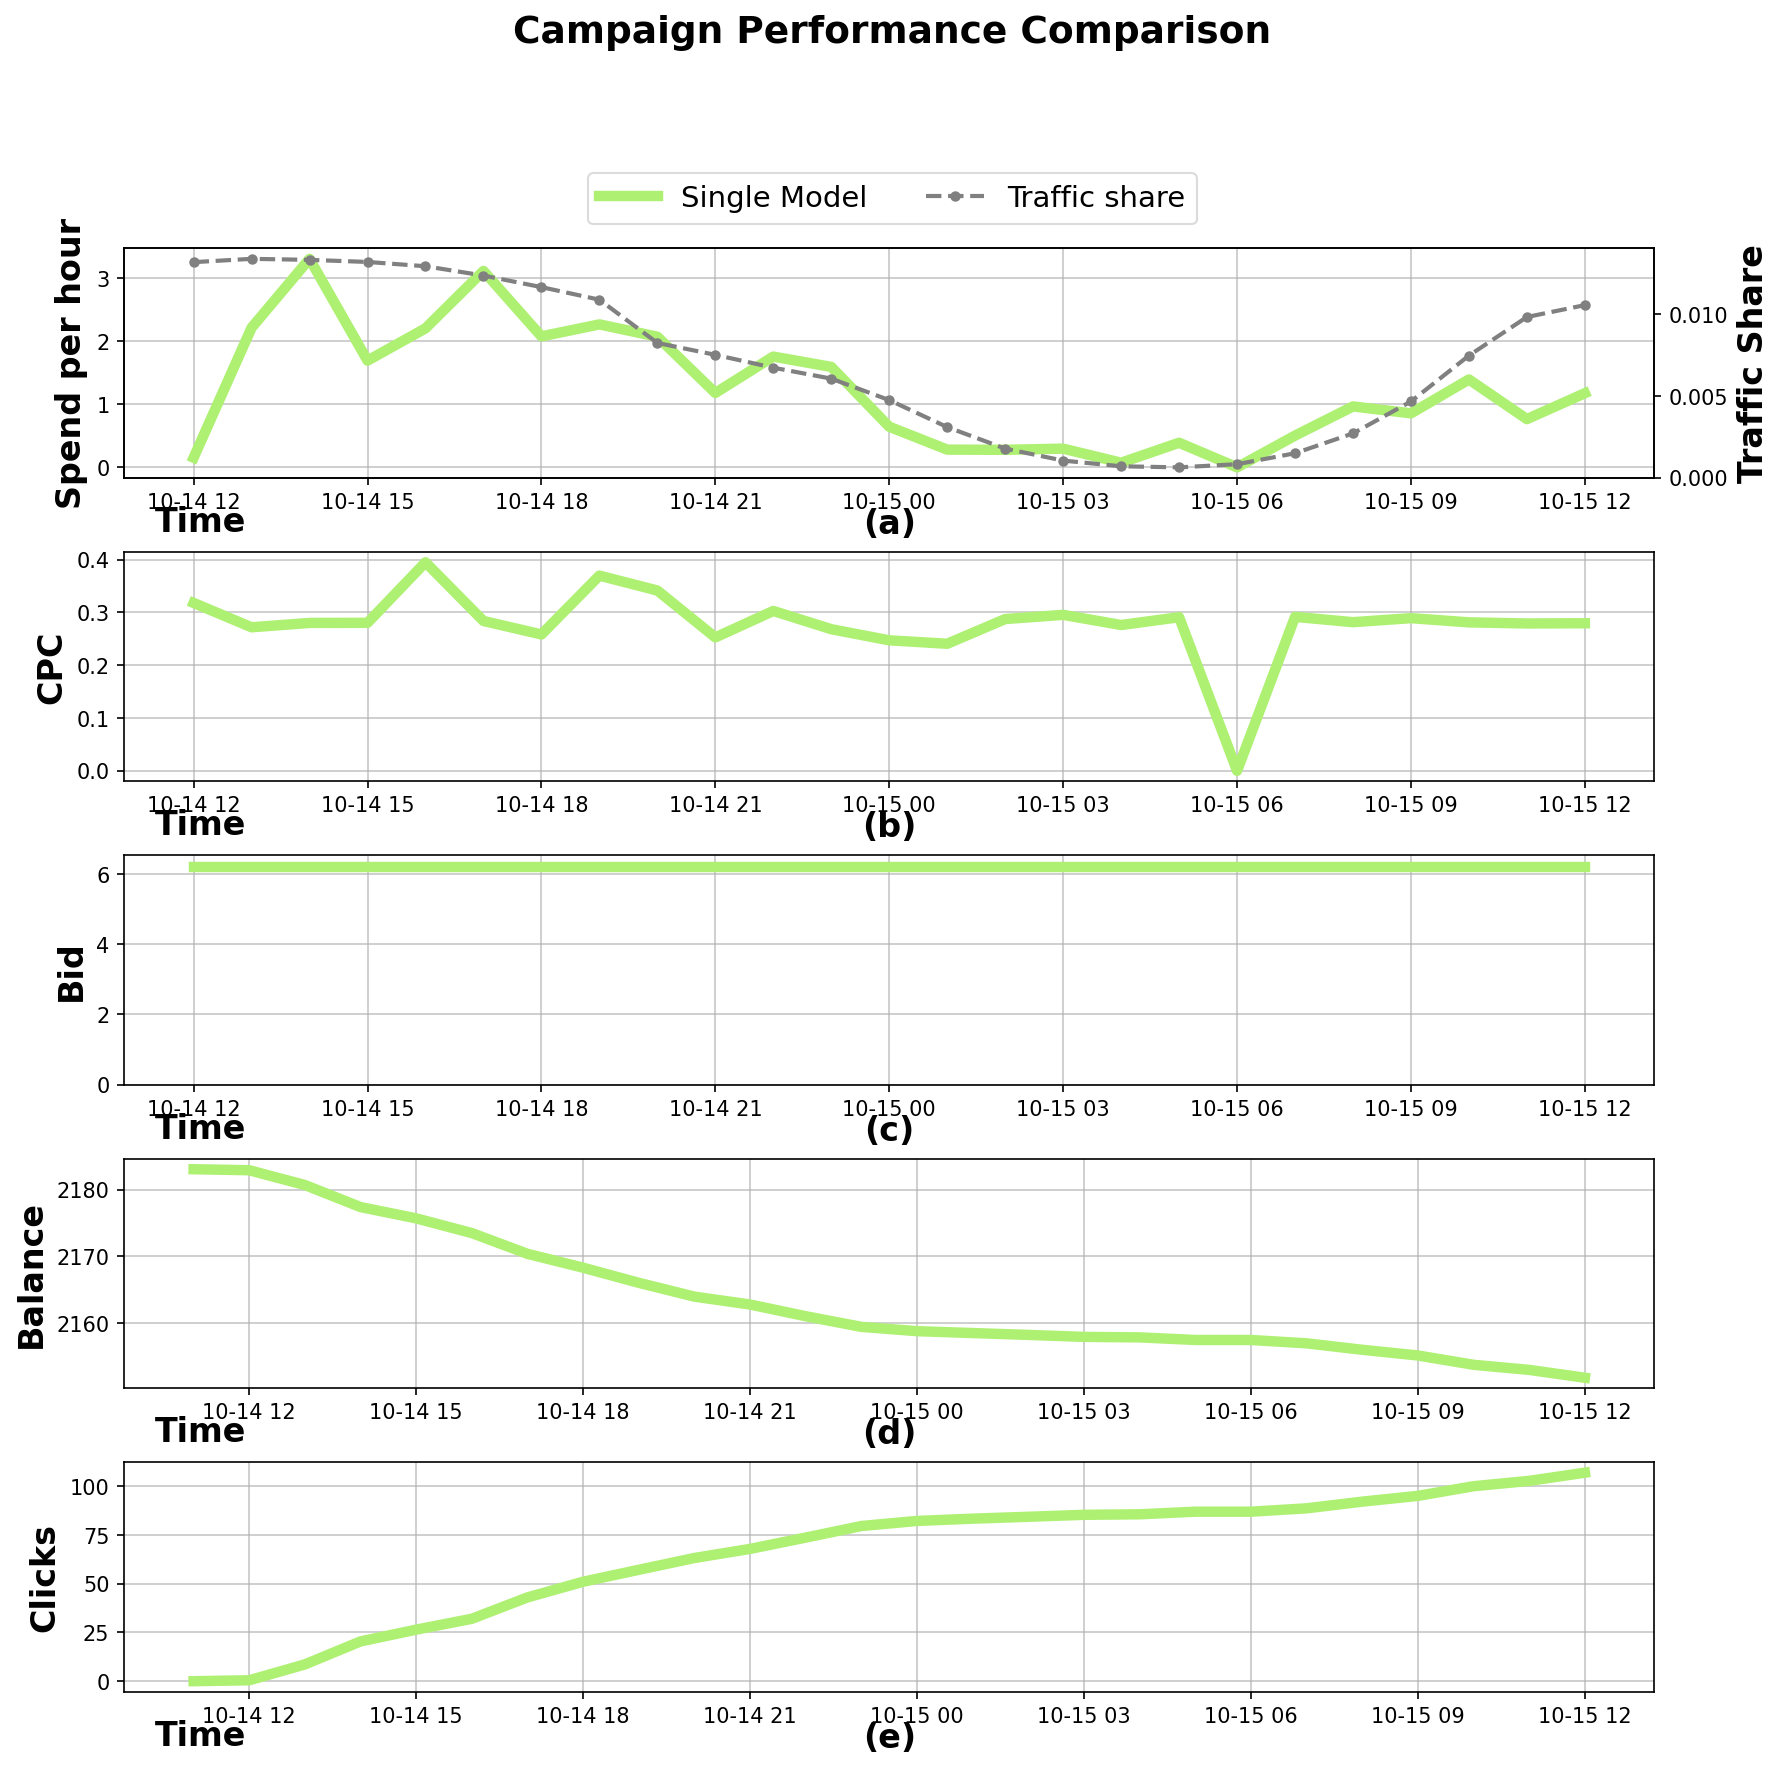

In [55]:
fig = plot_history_article(viz_data_broi)

## TA-PID Bidder

In [56]:
# refreshing Campaign
campaign_example = Campaign(
    item_id=campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  2183.04
Length hours  24


In [57]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=TAPIDBidder(),
    stats_file=campaign_stats,
    auction_mode=auction_mode
)

In [58]:
df = simulation_history.to_data_frame()
viz_data_ta_pid = data_prep_vis(df)
df.head(2)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-14 12:00:00,529664400,529663548,529749948,73593927,2125.189707,2183.04,1.394902,0.071621,807.7248,637640,637640,5.26,2278188,529660800,0,0,57.850293,1.394902,0.013186,0.013186,36.716566,41.472664
1,1986-10-14 13:00:00,529668000,529663548,529749948,73593927,1613.575891,2183.04,15.077067,0.705022,807.7248,637640,637640,5.26,2278188,529664400,0,0,511.613816,13.682165,0.013388,0.026574,36.716566,37.392752


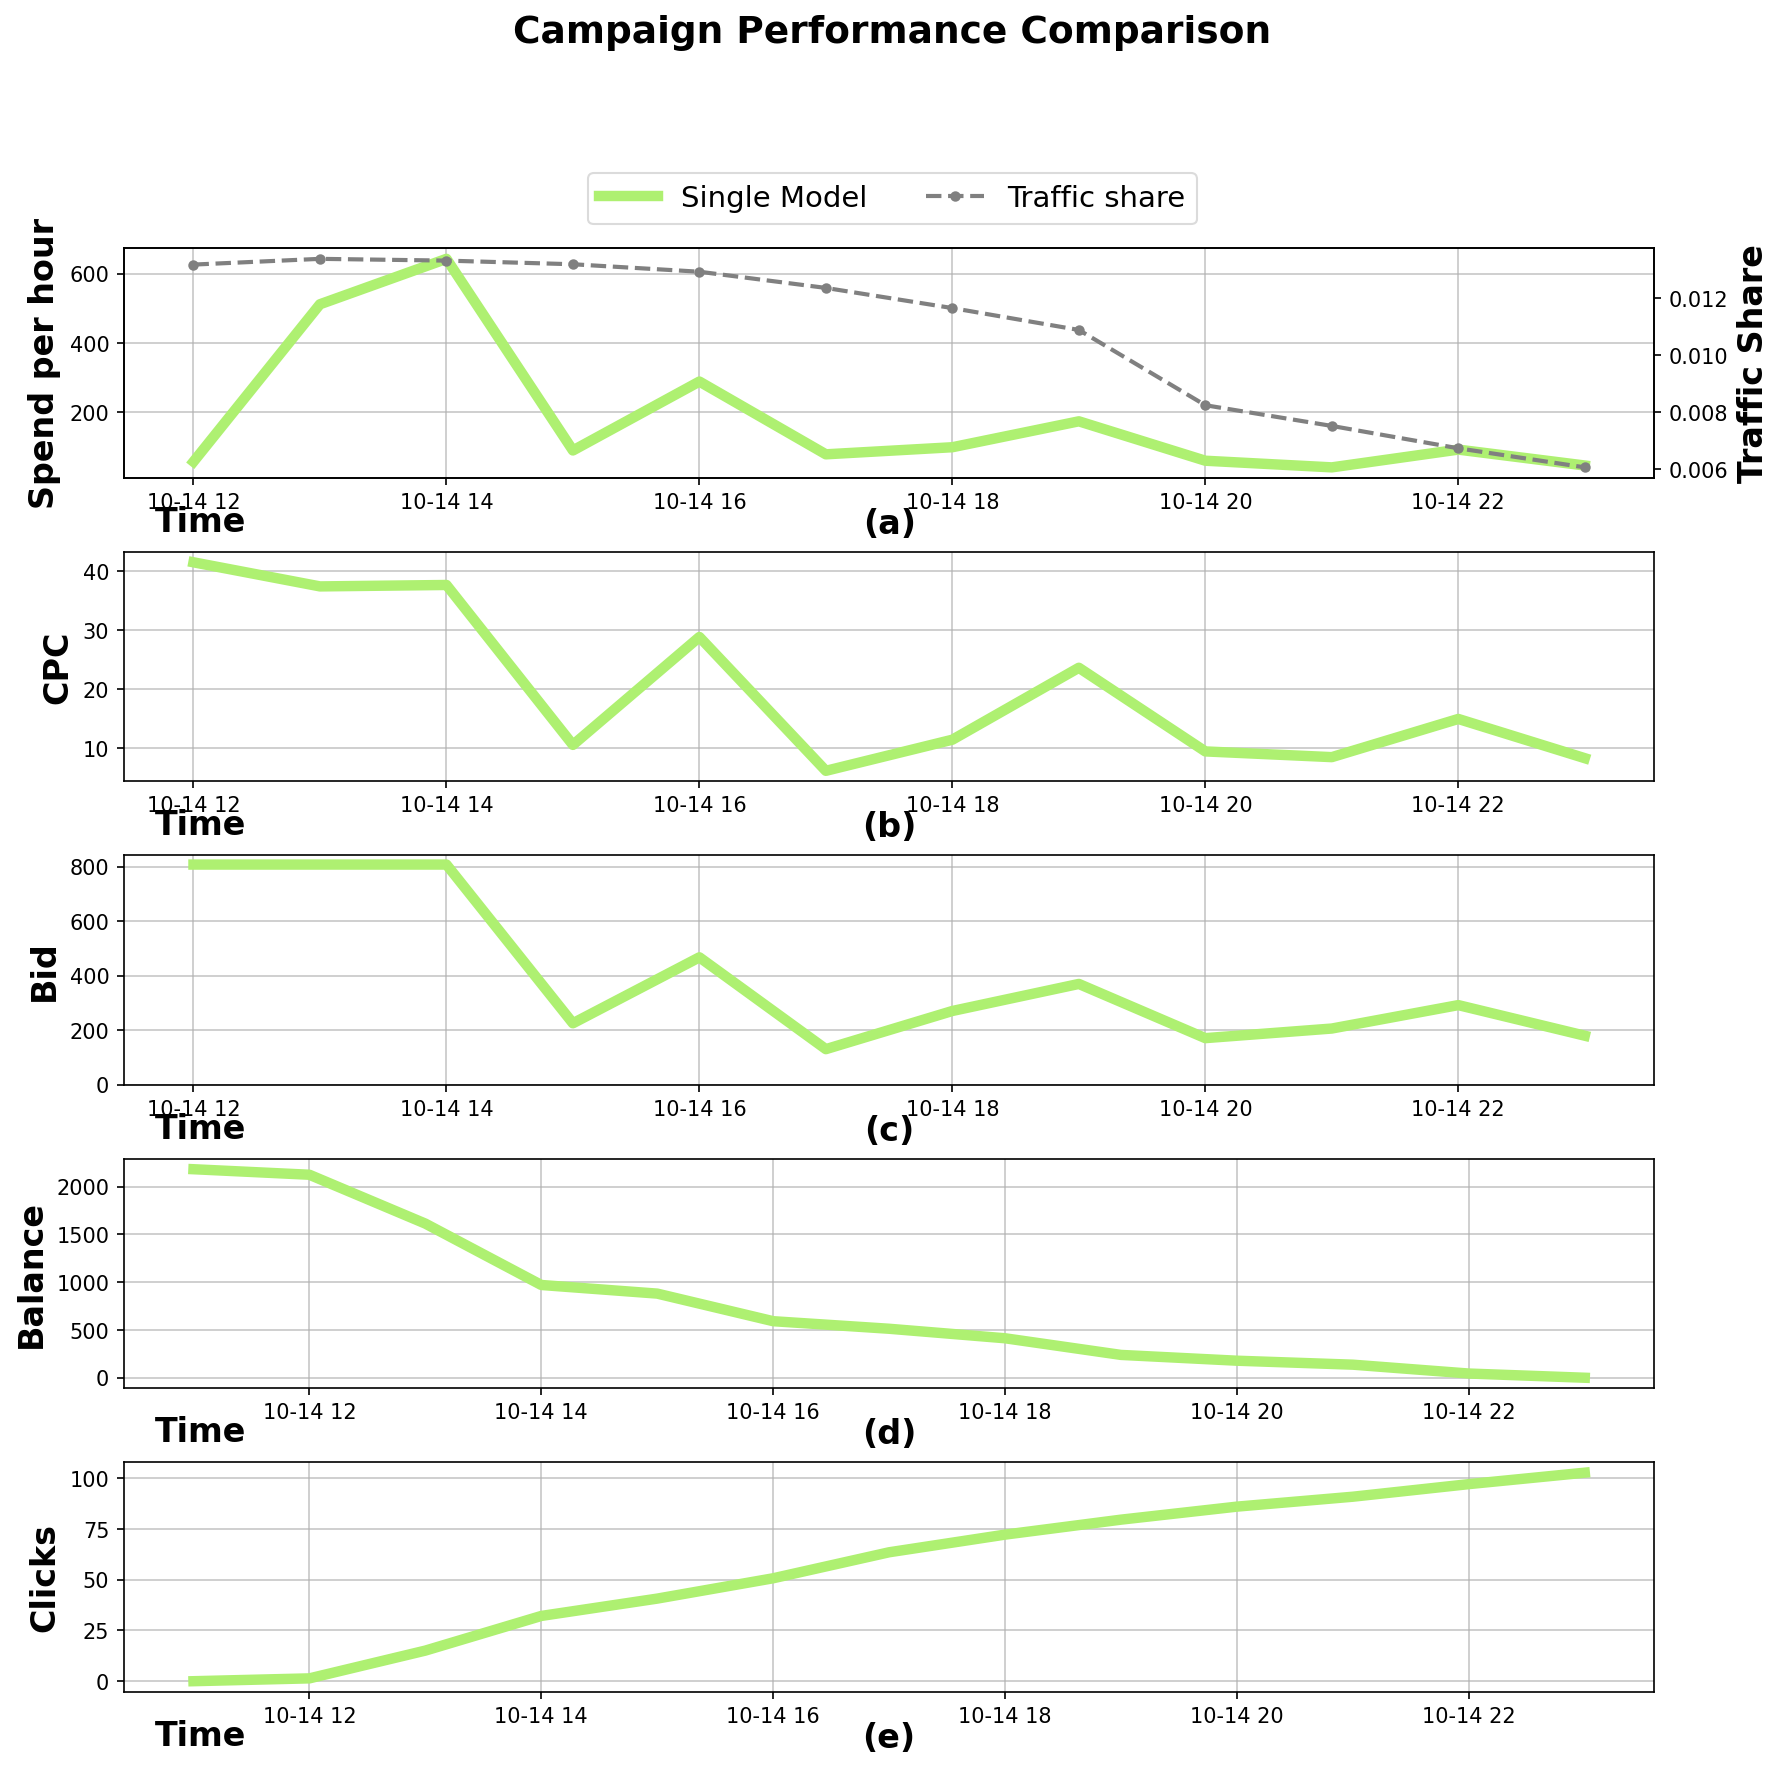

In [59]:
fig = plot_history_article(viz_data_ta_pid)

## M-PID Bidder

In [60]:
# refreshing Campaign
campaign_example = Campaign(
    item_id=campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  2183.04
Length hours  24


In [61]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=MPIDBidder(),
    stats_file=campaign_stats,
    auction_mode=auction_mode,
)

In [62]:
df = simulation_history.to_data_frame()
viz_data_m_pid = data_prep_vis(df)
df.head(10)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-14 12:00:00,529664400,529663548,529749948,73593927,2181.980005,2183.04,1.394902,0.071621,14.8,637640,637640,5.26,2278188,529660800,0,0,1.059995,1.394902,0.013186,0.013186,14.779531,0.759907
1,1986-10-14 13:00:00,529668000,529663548,529749948,73593927,2178.917830,2183.04,10.029842,0.454393,8.0,637640,637640,5.26,2278188,529664400,0,0,3.062174,8.634940,0.013388,0.026574,11.405352,0.354626
2,1986-10-14 14:00:00,529671600,529663548,529749948,73593927,2161.894228,2183.04,25.976219,1.201042,22.8,637640,637640,5.26,2278188,529668000,0,0,17.023602,15.946377,0.013326,0.039900,17.149703,1.067553
3,1986-10-14 15:00:00,529675200,529663548,529749948,73593927,2149.966813,2183.04,34.333933,1.593392,30.4,637640,637640,5.26,2278188,529671600,0,0,11.927415,8.357714,0.013198,0.053098,18.727586,1.427115
4,1986-10-14 16:00:00,529678800,529663548,529749948,73593927,2129.754375,2183.04,43.260665,2.125298,38.0,637640,637640,5.26,2278188,529675200,0,0,20.212438,8.926732,0.012935,0.066033,19.951487,2.264259
5,1986-10-14 17:00:00,529682400,529663548,529749948,73593927,2102.999003,2183.04,55.858164,2.712038,45.6,637640,637640,5.26,2278188,529678800,0,0,26.755372,12.597499,0.012366,0.078399,20.951487,2.123864
6,1986-10-14 18:00:00,529686000,529663548,529749948,73593927,2083.685606,2183.04,64.436093,3.075072,53.2,637640,637640,5.26,2278188,529682400,0,0,19.313397,8.577929,0.011658,0.090057,21.796975,2.251522
7,1986-10-14 19:00:00,529689600,529663548,529749948,73593927,2059.203873,2183.04,71.190507,3.477732,60.8,637640,637640,5.26,2278188,529686000,0,0,24.481733,6.754414,0.010889,0.100946,22.529370,3.624553
8,1986-10-14 20:00:00,529693200,529663548,529749948,73593927,2034.930017,2183.04,77.594235,3.832613,68.4,637640,637640,5.26,2278188,529689600,0,0,24.273856,6.403728,0.008244,0.109190,23.175388,3.790582
9,1986-10-14 21:00:00,529696800,529663548,529749948,73593927,2019.680511,2183.04,82.460050,4.033265,76.0,637640,637640,5.26,2278188,529693200,0,0,15.249507,4.865815,0.007516,0.116706,23.753271,3.134009


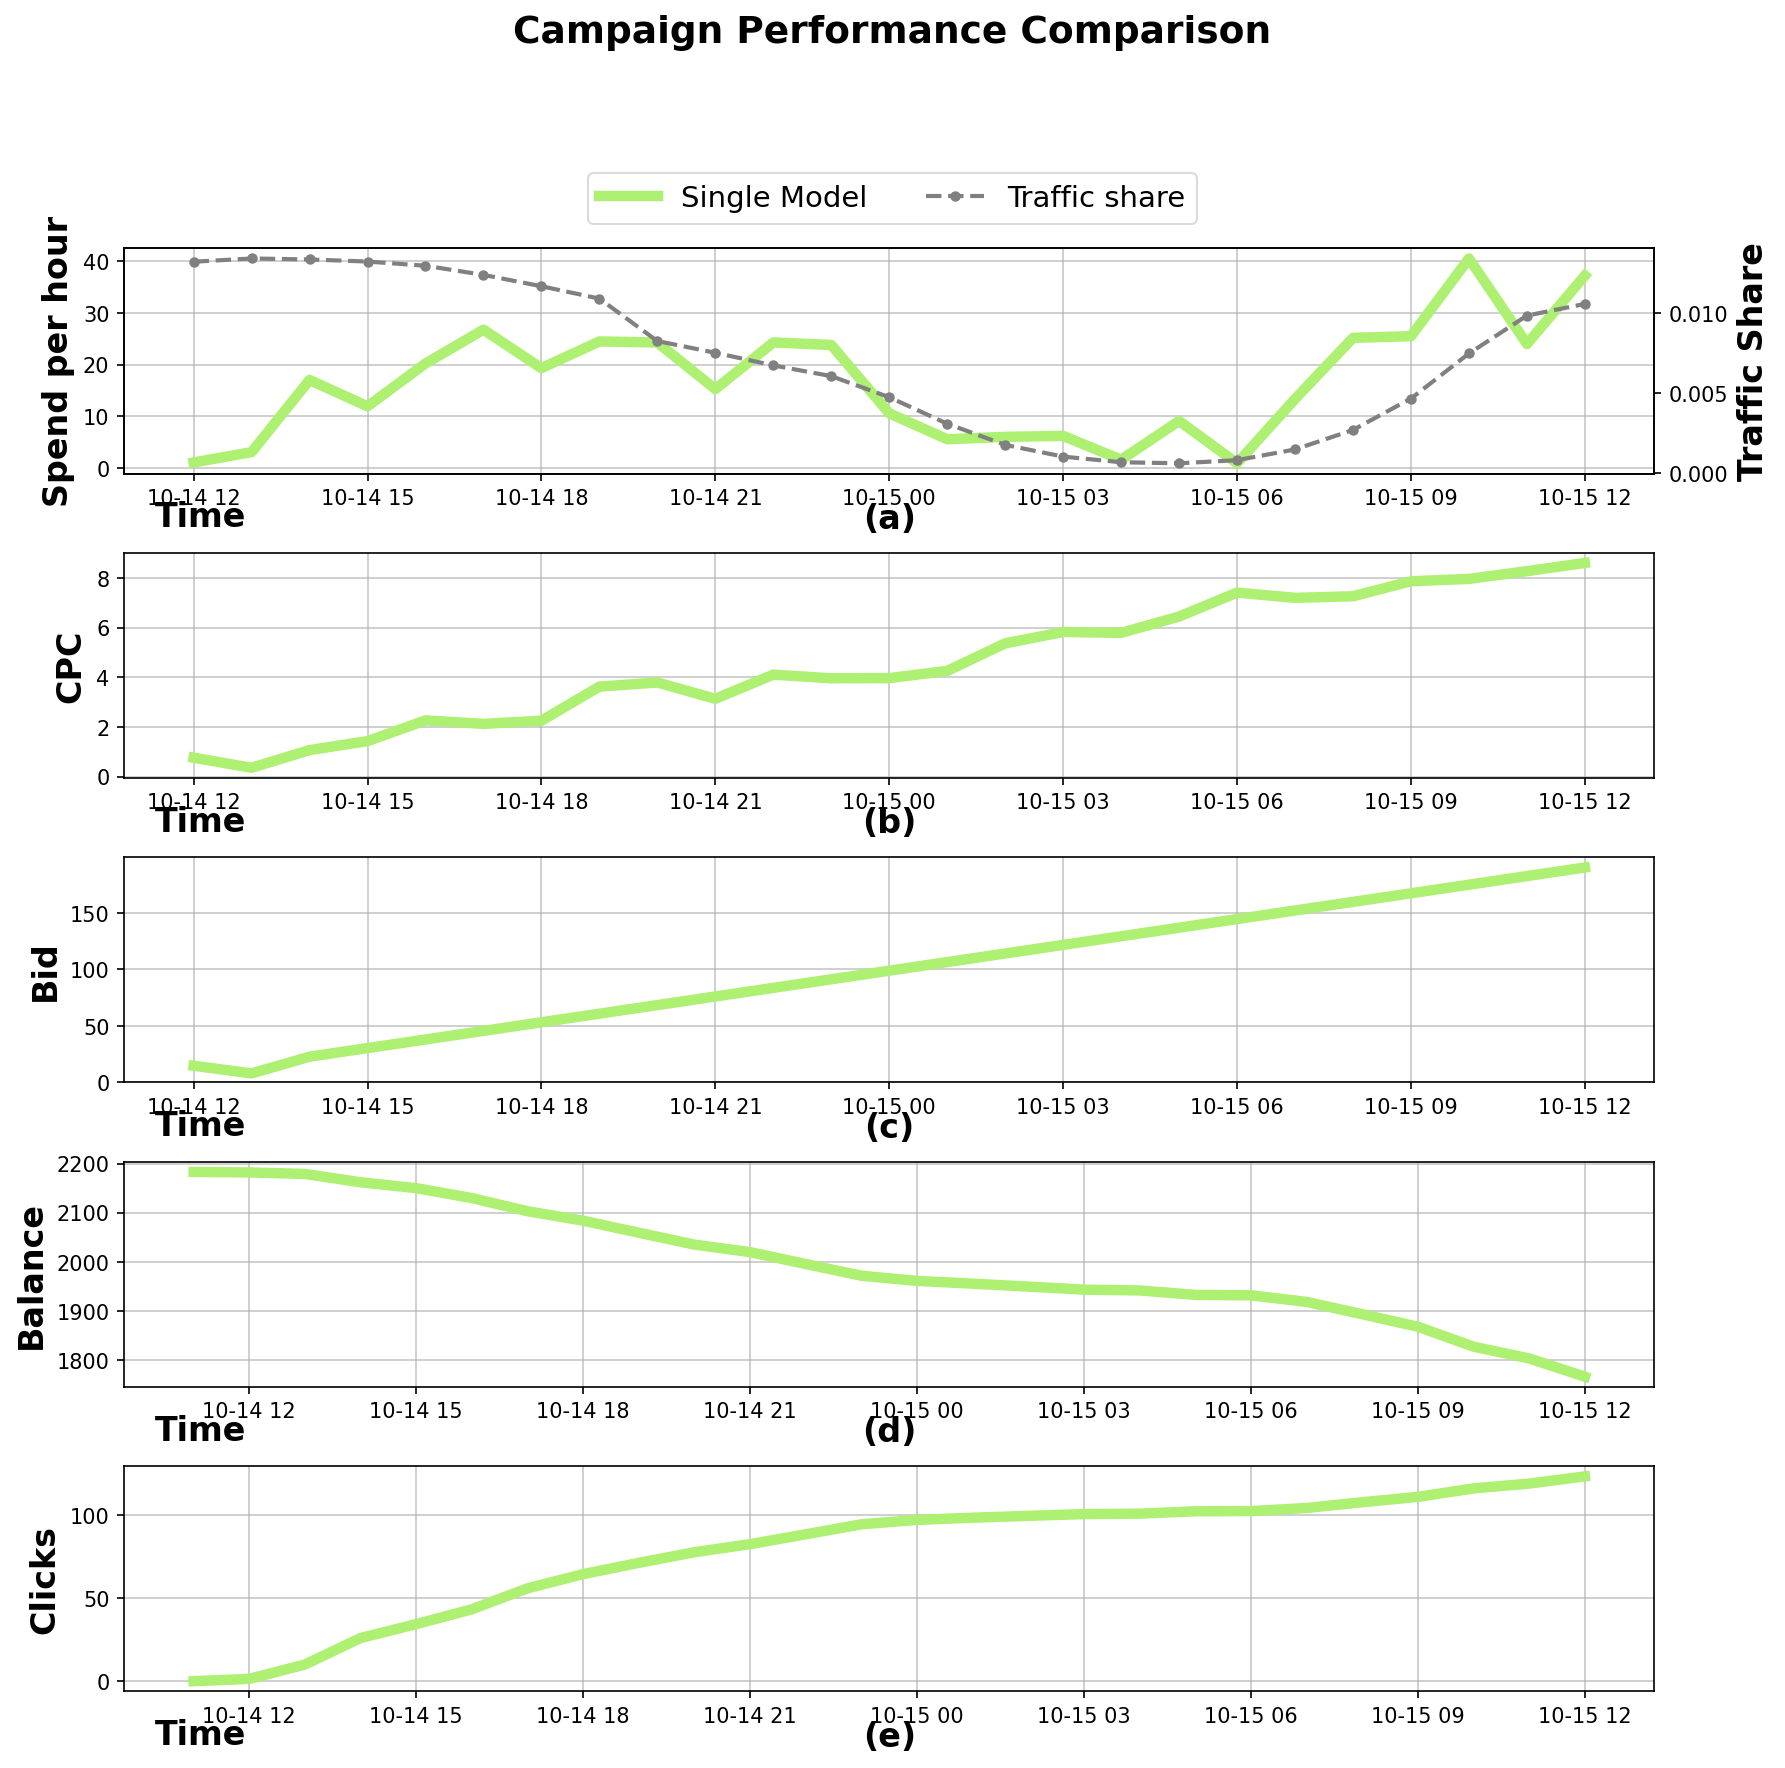

In [63]:
fig = plot_history_article(viz_data_m_pid)

In [64]:
# refreshing Campaign
campaign_example = Campaign(
    item_id=campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  2183.04
Length hours  24


In [65]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=BROI(),
    stats_file=campaign_stats,
    auction_mode=auction_mode,
)

In [66]:
df = simulation_history.to_data_frame()
viz_data_broi = data_prep_vis(df)
df.head(10)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-14 12:00:00,529664400,529663548,529749948,73593927,2182.886735,2183.04,0.482095,0.024753,6.191736,637640,637640,5.26,2278188,529660800,0,0,0.153265,0.482095,0.013186,0.013186,10.0,0.317915
1,1986-10-14 13:00:00,529668000,529663548,529749948,73593927,2180.674010,2183.04,8.622256,0.382121,6.191736,637640,637640,5.26,2278188,529664400,0,0,2.212724,8.140160,0.013388,0.026574,10.0,0.271828
2,1986-10-14 14:00:00,529671600,529663548,529749948,73593927,2177.369843,2183.04,20.420077,0.915762,6.191736,637640,637640,5.26,2278188,529668000,0,0,3.304167,11.797821,0.013326,0.039900,10.0,0.280066
3,1986-10-14 15:00:00,529675200,529663548,529749948,73593927,2175.678309,2183.04,26.455480,1.188954,6.191736,637640,637640,5.26,2278188,529671600,0,0,1.691534,6.035403,0.013198,0.053098,10.0,0.280269
4,1986-10-14 16:00:00,529678800,529663548,529749948,73593927,2173.475269,2183.04,32.034621,1.544757,6.191736,637640,637640,5.26,2278188,529675200,0,0,2.203040,5.579141,0.012935,0.066033,10.0,0.394871
5,1986-10-14 17:00:00,529682400,529663548,529749948,73593927,2170.362717,2183.04,43.004348,2.047452,6.191736,637640,637640,5.26,2278188,529678800,0,0,3.112552,10.969726,0.012366,0.078399,10.0,0.283740
6,1986-10-14 18:00:00,529686000,529663548,529749948,73593927,2168.287232,2183.04,51.039880,2.382654,6.191736,637640,637640,5.26,2278188,529682400,0,0,2.075485,8.035533,0.011658,0.090057,10.0,0.258288
7,1986-10-14 19:00:00,529689600,529663548,529749948,73593927,2166.021817,2183.04,57.168274,2.748532,6.191736,637640,637640,5.26,2278188,529686000,0,0,2.265415,6.128393,0.010889,0.100946,10.0,0.369659
8,1986-10-14 20:00:00,529693200,529663548,529749948,73593927,2163.951666,2183.04,63.230952,3.082872,6.191736,637640,637640,5.26,2278188,529689600,0,0,2.070151,6.062679,0.008244,0.109190,10.0,0.341458
9,1986-10-14 21:00:00,529696800,529663548,529749948,73593927,2162.772495,2183.04,67.897942,3.273315,6.191736,637640,637640,5.26,2278188,529693200,0,0,1.179171,4.666990,0.007516,0.116706,10.0,0.252662


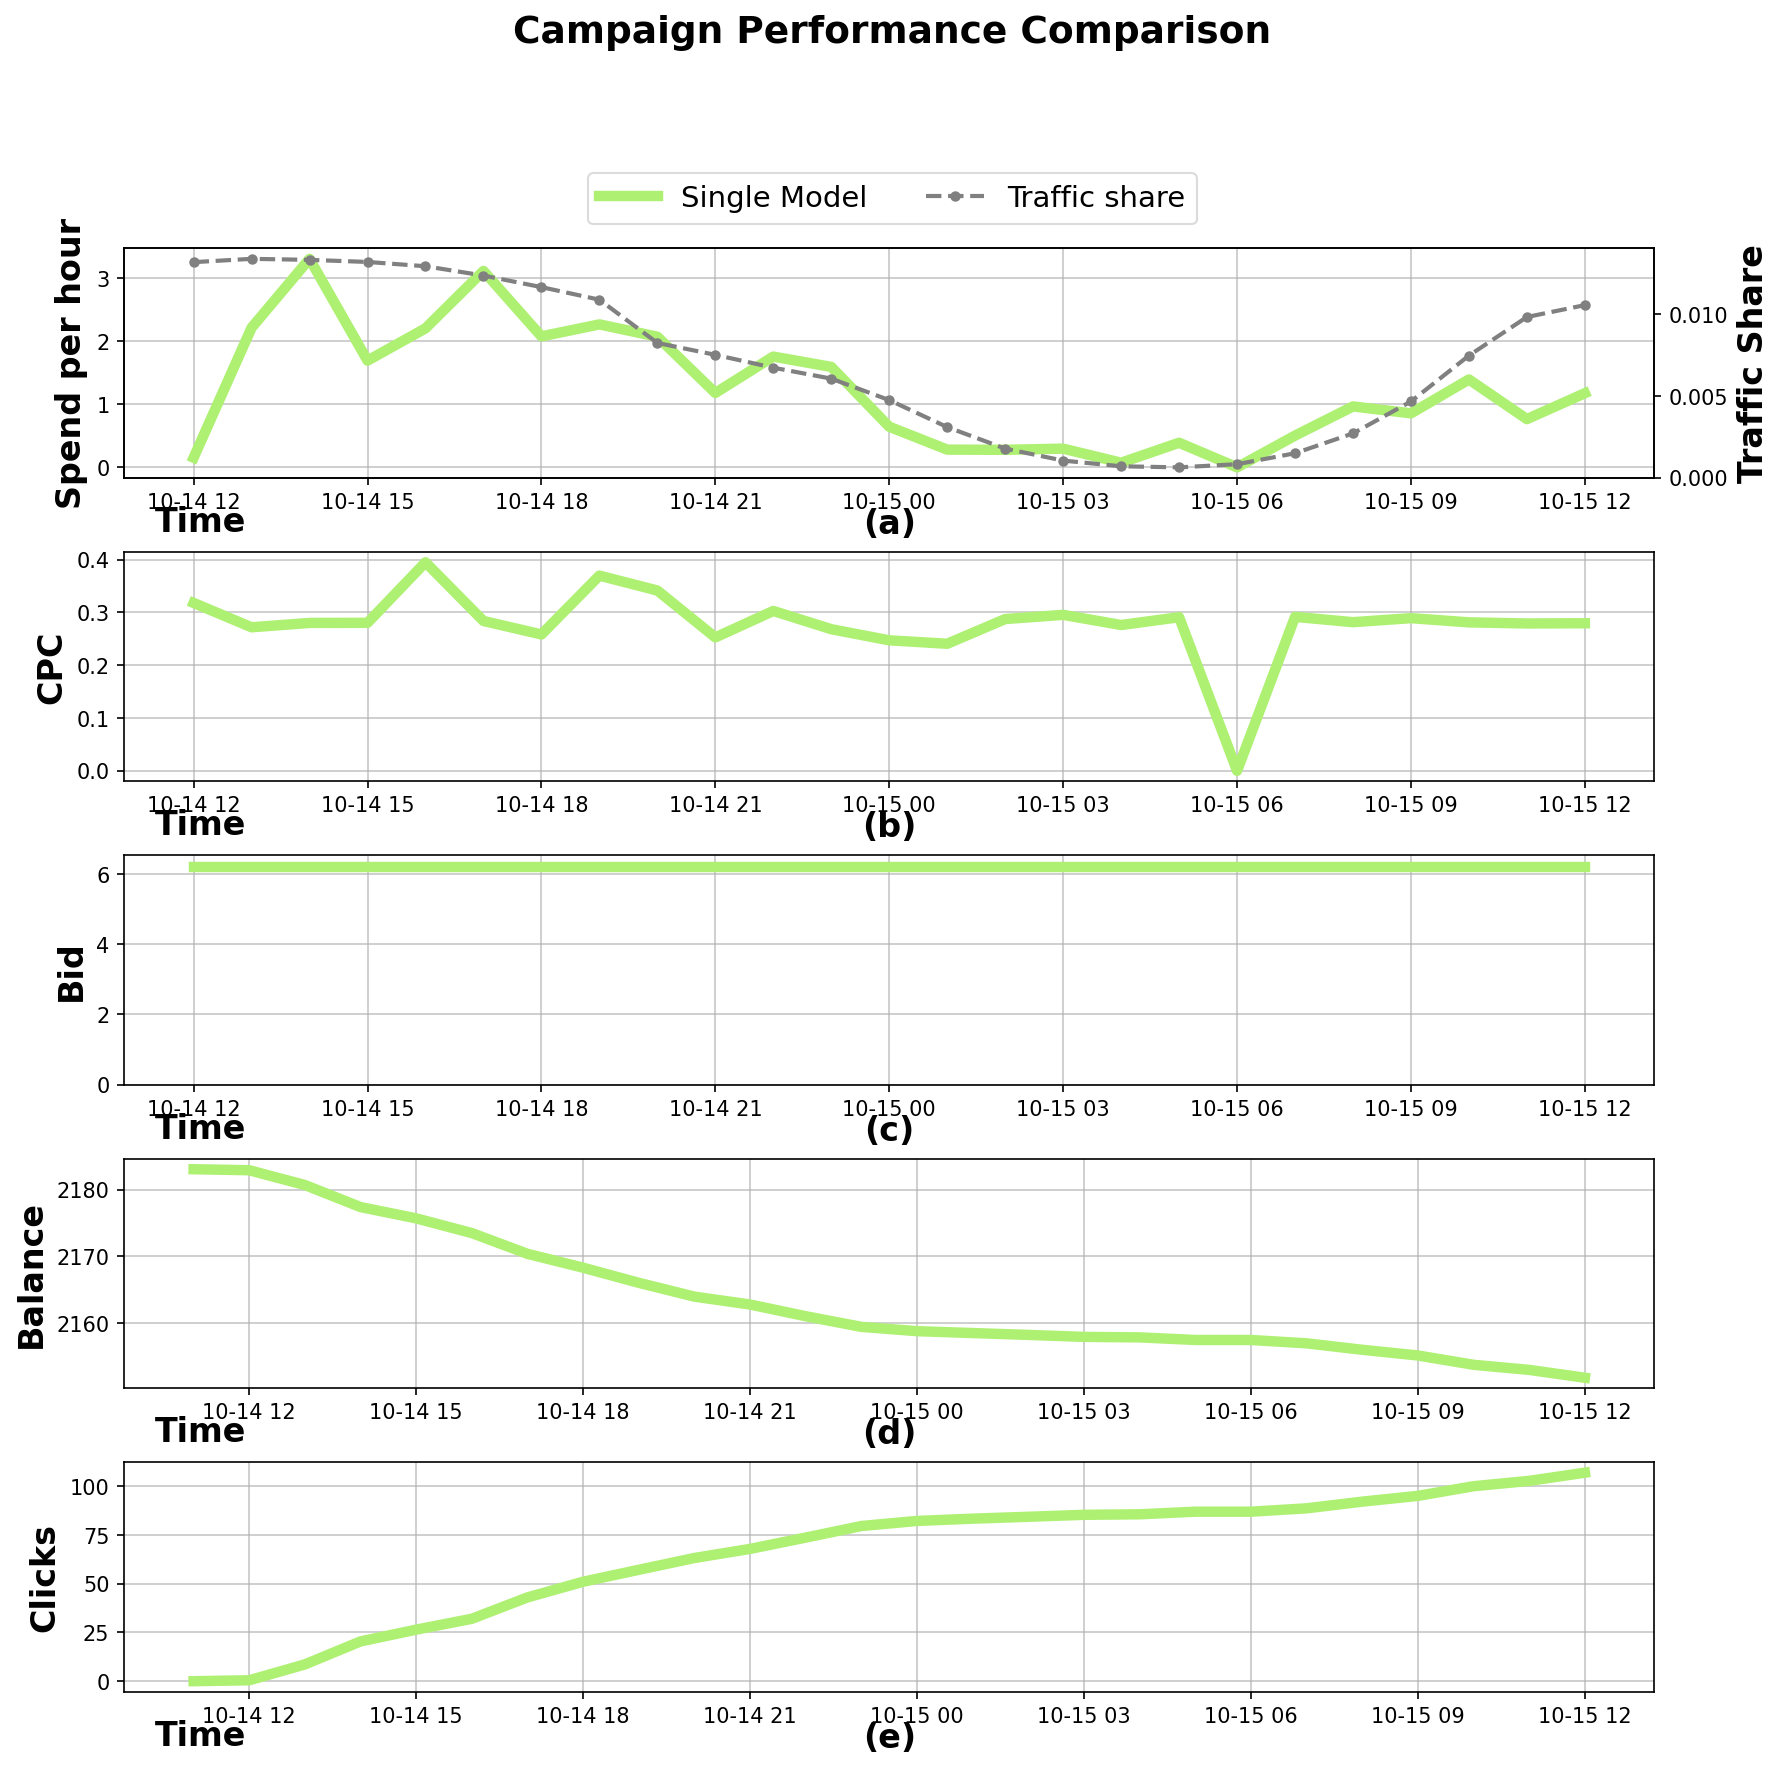

In [67]:
fig = plot_history_article(viz_data_broi)

## You may also compare the performance of all the baselines:

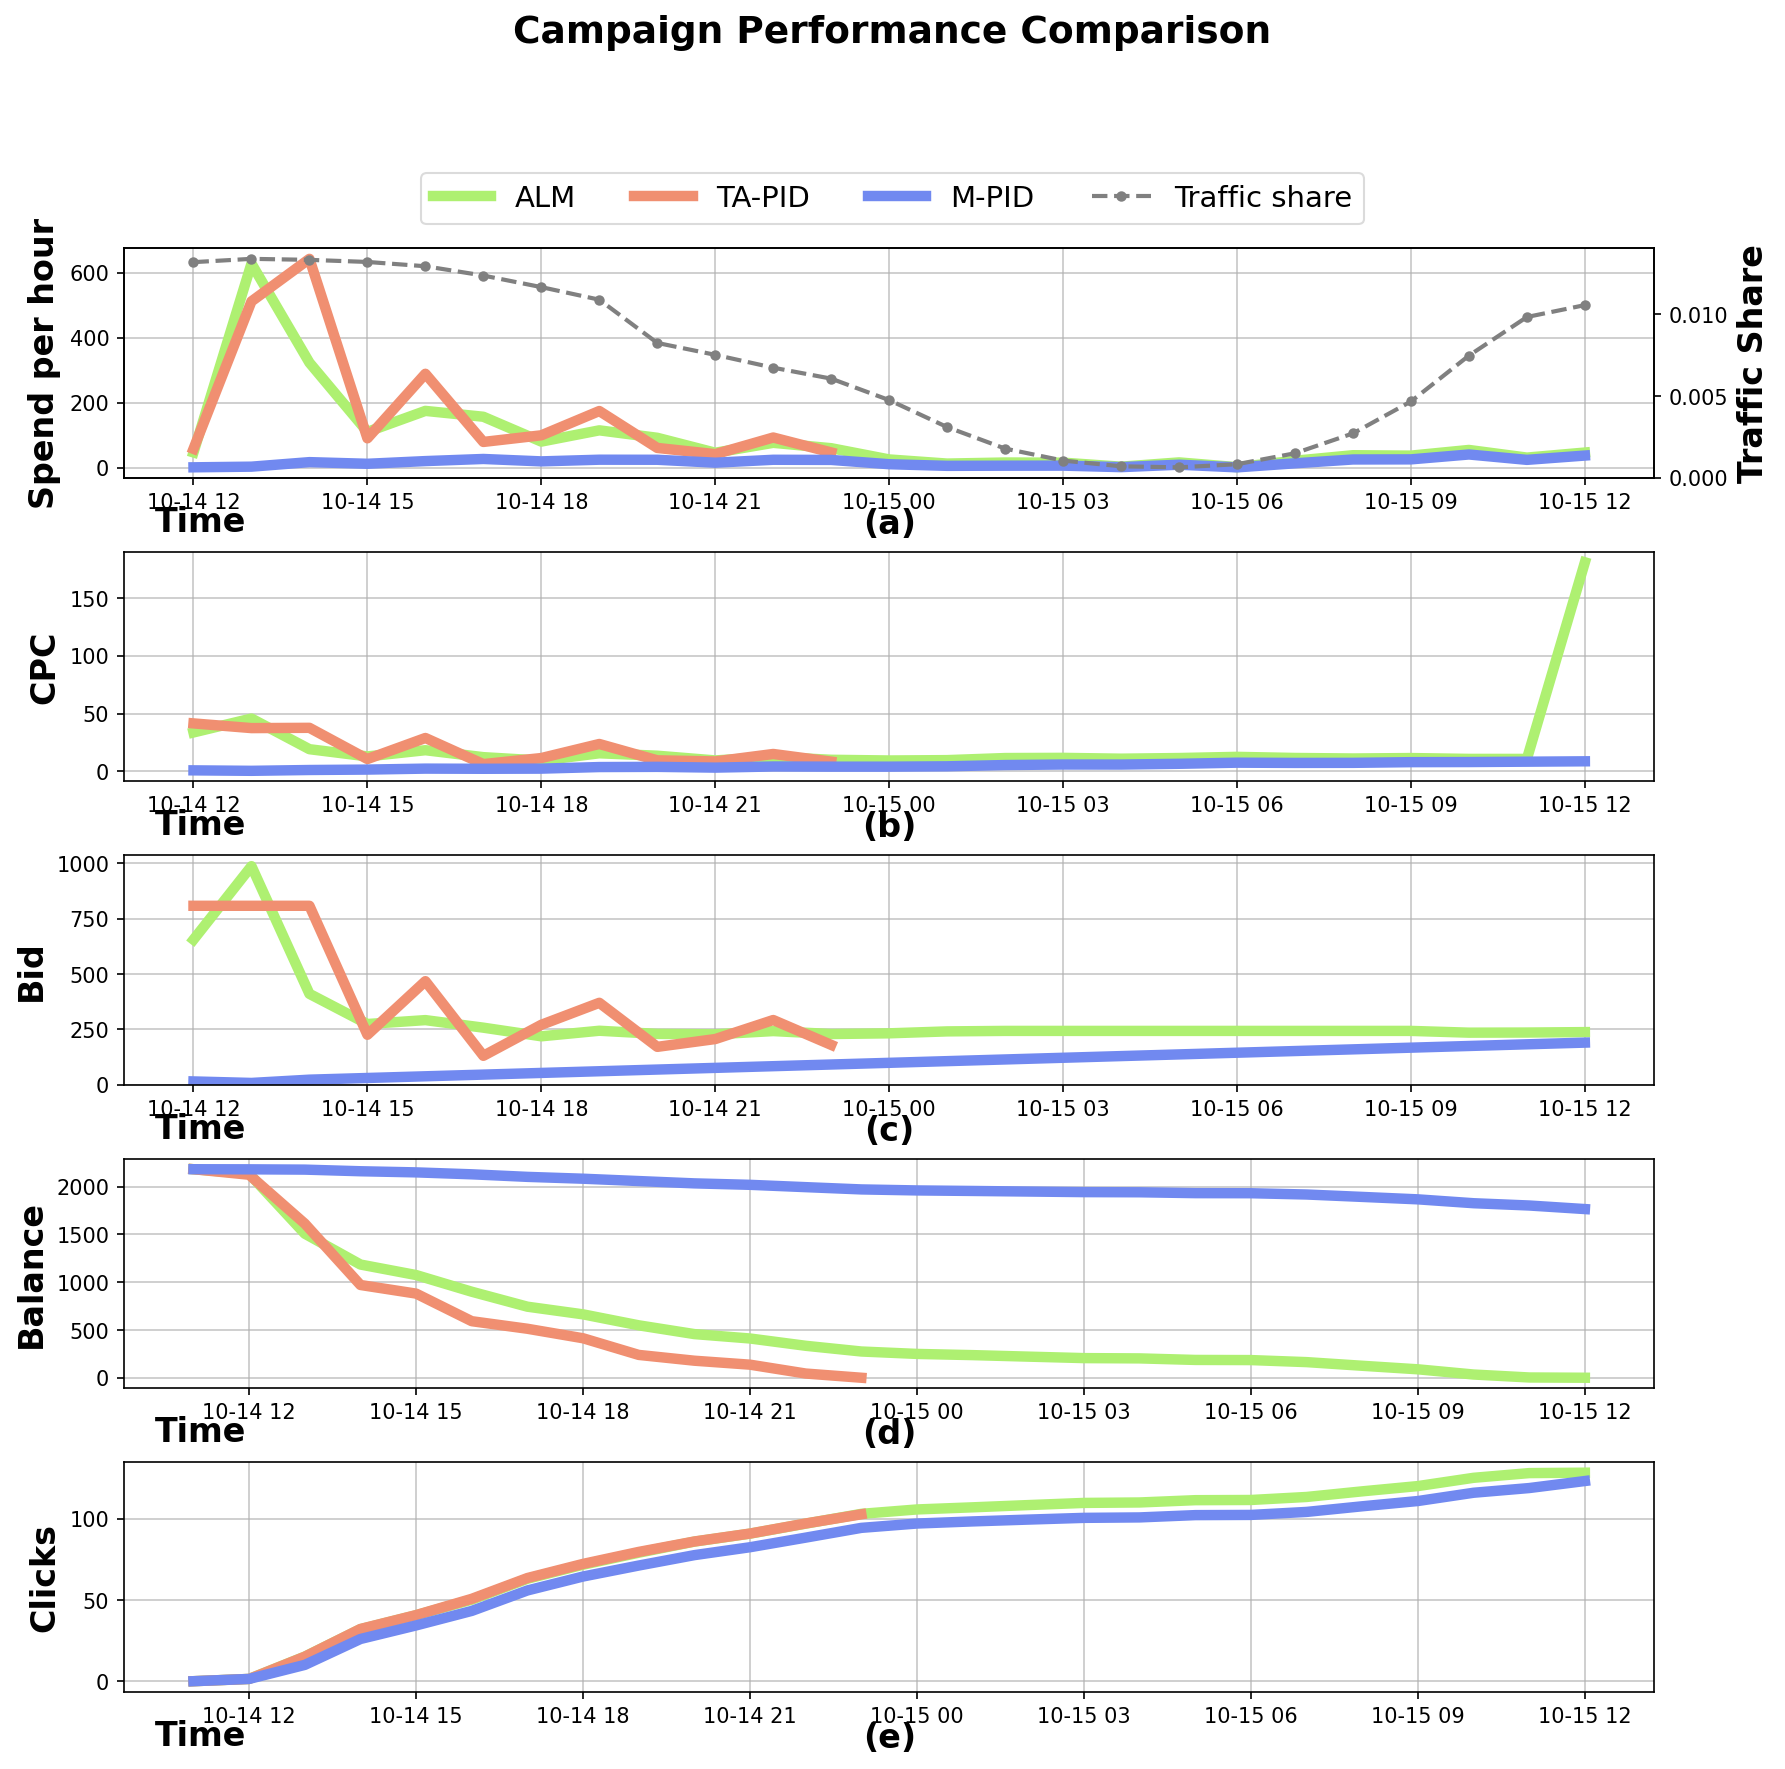

In [68]:
f = plot_history_article([viz_data_linear, viz_data_ta_pid, viz_data_m_pid], single_plot=False)

# Metrics

In [69]:
best_metrics = np.ones((3, 3)) * 100000

In [70]:
best_metrics

array([[100000., 100000., 100000.],
       [100000., 100000., 100000.],
       [100000., 100000., 100000.]])

### Mean 

## Linear Bidder

In [71]:
def objective_linear(trial, metric='RMSE_T', auction_mode='FPA'):
    coef = trial.suggest_float('coef', 0.001, 0.999, log=True) # Cold start coefficient
    lower_clip = trial.suggest_int('lower_clip', 1, 20, log=True)
    upper_clip = trial.suggest_int('upper_clip', 1, 20, log=True)
    factor = trial.suggest_float('factor', 1.1, 10.0, log=True)
   
    res = autobidder_check(
        bidder=LinearBidder,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "cold_start_coef": coef,
            "lower_clip": lower_clip,
            "upper_clip": upper_clip,
            "factor": factor # slope
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
      
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 

    
def opt_search_linear(n_trials=100, metric='RMSE_T', auction_mode='FPA'):
    # Create pruner
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10,
        interval_steps=1
    )

    # Create study with pruner
    study = optuna.create_study(
        direction='maximize' if (metric == 'MCR') else 'minimize',
        pruner=pruner
    )

    # Optimization
    study.optimize(
        partial(objective_linear, metric=metric, auction_mode=auction_mode),
        n_trials=n_trials,
        catch=(Exception,)
    )

    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/linear_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [72]:
# n = 10
# metric = 'RMSE_T' # for Mean Click Ratio use 'MCR'
# study_linear = opt_search_linear(n, metric, auction_mode)

In [73]:
# n = 10
# metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
# study_linear = opt_search_linear(n, metric, auction_mode)

In [74]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_linear(n, metric, auction_mode)

[I 2026-02-19 14:18:37,176] A new study created in memory with name: no-name-d9da653d-ce70-488d-b26d-28e6bee8310f


[I 2026-02-19 14:19:59,951] Trial 0 finished with value: 27739.614710870046 and parameters: {'coef': 0.5217450080211877, 'lower_clip': 2, 'upper_clip': 3, 'factor': 8.452666238415063}. Best is trial 0 with value: 27739.614710870046.


CPC_REL: 4.884343122701312, rmse: 3.1359413554845346, SCR: 27739.614710870046


[I 2026-02-19 14:21:32,643] Trial 1 finished with value: 31743.56854924731 and parameters: {'coef': 0.1868659088186542, 'lower_clip': 1, 'upper_clip': 4, 'factor': 2.128601774881344}. Best is trial 1 with value: 31743.56854924731.


CPC_REL: 4.374977955506096, rmse: 2.0092459841918084, SCR: 31743.56854924731


...

CPC_REL: 540.682825717592, rmse: 1.2685370554223014, SCR: 31355.854635436706


[I 2026-02-19 14:32:59,548] Trial 8 finished with value: 34492.03706379812 and parameters: {'coef': 0.20938632568261153, 'lower_clip': 1, 'upper_clip': 1, 'factor': 6.37215325416488}. Best is trial 8 with value: 34492.03706379812.


CPC_REL: 42.420399536016156, rmse: 1.5558127104692057, SCR: 34492.03706379812


[I 2026-02-19 14:34:42,437] Trial 9 finished with value: 34722.99602260807 and parameters: {'coef': 0.42208289274855354, 'lower_clip': 9, 'upper_clip': 1, 'factor': 2.9899159167098985}. Best is trial 9 with value: 34722.99602260807.


CPC_REL: 3.612865535051418, rmse: 1.6952161847159448, SCR: 34722.99602260807
Best trial:
  Value: 34722.99602260807
  Params: 
    coef: 0.42208289274855354
    lower_clip: 9
    upper_clip: 1
    factor: 2.9899159167098985


## TA-PID Bidder

In [90]:
def objective_tapid(trial, metric='RMSE_T', auction_mode='FPA'):
    k_p1 = trial.suggest_float('k_p1', 1e-4, 1, log=True)
    k_i1 = trial.suggest_float('k_i1', 1e-4, 1, log=True)
    k_d1 = trial.suggest_float('k_d1', 1e-4, 1, log=True)
    coef = trial.suggest_float('coef', 0.1, 0.9, log=True) # Cold start coefficient
    k_dict = {
        'k_p': k_p1,
        'k_i': k_i1,
        'k_d': k_d1
    }
   
    res = autobidder_check(
        bidder=TAPIDBidder,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "k_dict": k_dict, 
            'cold_start_coef': coef,
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
        print(f'PROBLEMS???{abs(1 - res["score"][0])}')
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 

def opt_search_tapid(n_trials, metric, auction_mode='FPA'):
    # if metric == 'RMSE_T':
    study = optuna.create_study(
        direction='maximize' if metric == 'MCR' else 'minimize'
    )
    # elif metric == 'MCR':
    #     study = optuna.create_study(direction='maximize')
    study.optimize(partial(objective_tapid, metric=metric, auction_mode=auction_mode), n_trials=n_trials)

    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/ta_pid_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [91]:
# n = 10
# metric = 'RMSE_T' # for Mean Click Ratio use 'MCR'
# study_ta_pid = opt_search_tapid(n, metric, auction_mode)

In [92]:
# n = 10
# metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
# study_ta_pid = opt_search_tapid(n, metric, auction_mode)

In [93]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_tapid(n, metric, auction_mode)

[I 2026-02-19 15:52:14,499] A new study created in memory with name: no-name-e5041286-f859-4018-a74d-91c657390f79


[I 2026-02-19 15:53:26,457] Trial 0 finished with value: 23865.534135175123 and parameters: {'k_p1': 0.004817896319311281, 'k_i1': 0.14067405908291855, 'k_d1': 0.00042047985875747645, 'coef': 0.13128468634248147}. Best is trial 0 with value: 23865.534135175123.


CPC_REL: 9.836055990762512, rmse: 3.628739745902295, SCR: 23865.534135175123


[I 2026-02-19 15:54:40,418] Trial 1 finished with value: 30293.9964122132 and parameters: {'k_p1': 0.2266529939361817, 'k_i1': 0.2502101085012333, 'k_d1': 0.006082165439187011, 'coef': 0.27312199261324727}. Best is trial 1 with value: 30293.9964122132.


CPC_REL: 2.6596266100463333, rmse: 3.4113323934752304, SCR: 30293.9964122132


...

CPC_REL: 212.2047750010528, rmse: 2.295036627058461, SCR: 26198.97262994913


[I 2026-02-19 16:02:41,325] Trial 8 finished with value: 23354.642097534954 and parameters: {'k_p1': 0.0007160818108589976, 'k_i1': 0.9260261671429572, 'k_d1': 0.010451839353004502, 'coef': 0.170289256166935}. Best is trial 3 with value: 30523.84873642461.


CPC_REL: 2.329119136766238, rmse: 3.4532919437449814, SCR: 23354.642097534954


[I 2026-02-19 16:03:46,863] Trial 9 finished with value: 26544.303070569542 and parameters: {'k_p1': 0.006965561774515367, 'k_i1': 0.010544876459950225, 'k_d1': 0.07022516795032402, 'coef': 0.8568564665402306}. Best is trial 3 with value: 30523.84873642461.


CPC_REL: 66.07418048805914, rmse: 2.339248643332356, SCR: 26544.303070569542
Best trial:
  Value: 30523.84873642461
  Params: 
    k_p1: 0.6452882569334741
    k_i1: 0.003844584939940269
    k_d1: 0.16900208483415294
    coef: 0.36744408651482396


In [12]:
best_metrics

NameError: name 'best_metrics' is not defined

## M-PID Bidder

In [ ]:
def objective_mpid(trial, metric='RMSE_T', auction_mode='FPA'):
    k_p1 = trial.suggest_float('k_p1', 1e-4, 1, log=True)
    k_p2 = trial.suggest_float('k_p2', 1e-4, 1, log=True)
    k_i1 = trial.suggest_float('k_i1', 1e-4, 1, log=True)
    k_i2 = trial.suggest_float('k_i2', 1e-4, 1, log=True)
    k_d1 = trial.suggest_float('k_d1', 1e-4, 1, log=True)
    k_d2 = trial.suggest_float('k_d2', 1e-4, 1, log=True)
    alpha = trial.suggest_float('alpha', 0.1, 0.9, log=True)
    beta = trial.suggest_float('beta', 0.1, 0.9, log=True)
    coef = trial.suggest_float('coef', 0.1, 0.9, log=True) # Cold start coefficient
    lower_clip = trial.suggest_float('lower_clip', 0.1, 0.9, log=True)
    upper_clip = trial.suggest_float('upper_clip', 1.5, 10, log=True)
    bid_factor = trial.suggest_float('bid_factor', 0.5, 20.0, log=True)
    temp_coef = 1.0
    
    k_dict = {
        'k_p': (k_p1, k_p2),
        'k_i': (k_i1, k_i2),
        'k_d': (k_d1, k_d2)
    }
   
    res = autobidder_check(
        bidder=MPIDBidder,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "k_dict": k_dict, 
            "correction": [alpha, beta],
            'cold_start_coef': coef,
            'lower_clip': lower_clip, 
            'upper_clip': upper_clip, 
            'bid_factor': bid_factor},
        auction_mode=auction_mode,
    )
    
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    
    # if metric == 'RMSE_T':
    #     best_metrics[2, 0] = min(best_metrics[2, 0], res['score'][1])
    #     return res['score'][1] 
    # elif metric == 'CPC_REL':
    #     best_metrics[2, 1] = min(best_metrics[2, 1], res['score'][0])
    #     return res['score'][0] 
    # elif metric == 'MCR':
    #     best_metrics[2, 2] = max(best_metrics[2, 2], res['score'][2])
    #     return res['score'][2]

def opt_search_mpid(n_trials, metric='RMSE_T', auction_mode='FPA'):
    # if metric == 'RMSE_T':
    study = optuna.create_study(direction='maximize' if (metric == 'MCR') else 'minimize')
    # elif metric == 'MCR':
    #     study = optuna.create_study(direction='maximize')
    study.optimize(partial(objective_mpid, metric=metric, auction_mode=auction_mode), n_trials=n_trials, n_jobs=6)

    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [7]:
# n = 10
# metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
# study_m_pid = opt_search_mpid(n, metric, auction_mode)

In [ ]:
n = 1
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_m_pid = opt_search_mpid(n, metric, auction_mode)

[I 2026-02-23 23:02:25,993] A new study created in memory with name: no-name-aacdb028-27fc-4639-a2ff-08b2145c47b5


In [ ]:
# n = 10
# metric = 'RMSE_T' # for Mean Click Ratio use 'MCR'
# study_m_pid = opt_search_mpid(n, metric, auction_mode)

In [ ]:
# print('VCG, RMSE_T| REL_CPC| RMSE_T+REL_CPC: ')
# np.set_printoptions(precision=5,suppress=True)
# print('Linear', best_metrics[0])
# print('TA-PID', best_metrics[1])
# print('M-PID', best_metrics[2])

In [ ]:
print('FPA, RMSE_T| REL_CPC| RMSE_T+REL_CPC: ')
np.set_printoptions(precision=5,suppress=True)
print('Linear', best_metrics[0])
print('TA-PID', best_metrics[1])
print('M-PID', best_metrics[2])

FPA, RMSE_T| REL_CPC| RMSE_T+REL_CPC: 
Linear [ 100000.       100000.      1897957.18778]
TA-PID [100000. 100000. 100000.]
M-PID [ 100000.       100000.      1624004.54892]


# Mystique bidder

In [46]:
def objective_mystique(trial, metric='RMSE_T', auction_mode='FPA'):
   

    pf0 = trial.suggest_float('pf0', 1, 200, log=True)
    C_max = trial.suggest_float('C_max', 1, 100, log=True)
    C_min = trial.suggest_float('C_min', 1e-4, 1, log=True)
    E_max = trial.suggest_float('E_max', 1, 100, log=True)
    E_gmc = trial.suggest_float('E_gmc', 1, 100, log=True)
   
    res = autobidder_check(
        bidder=Mystique,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "pf0": pf0, 
            "C_max": C_max,
            'C_min': C_min,
            'E_max': E_max, 
            'E_gmc': E_gmc},
        auction_mode=auction_mode,
    )

    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        return res['score'][1] 
    elif metric == 'CPC_REL':
        return res['score'][0] 
    elif metric == 'MCR':
        return res['score'][2] 

def opt_search_mystique(n_trials, metric='RMSE_T', auction_mode='FPA'): 
    study = optuna.create_study(direction='maximize' if metric == 'MCR' else 'minimize')
    study.optimize(partial(objective_mystique, metric=metric, auction_mode=auction_mode), n_trials=n_trials, n_jobs=6)
    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/mystique_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [47]:
# n = 10
# metric = 'RMSE_T' # for Mean Click Ratio use 'MCR'
# study_mystique = opt_search_mystique(n, metric,  auction_mode)

In [48]:
# n = 10
# metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
# study_mystique = opt_search_mystique(n, metric,  auction_mode)

In [ ]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_mystique = opt_search_mystique(n, metric, auction_mode)

[I 2026-02-18 19:58:58,737] A new study created in memory with name: no-name-40a5b92a-3059-4d71-92cd-fee3c74683e5


### BROI

In [ ]:
def objective_broi(trial, metric='RMSE_T', auction_mode='FPA'):
    ro = trial.suggest_float('ro', 0.01, 200, log=True)
    v_bar = trial.suggest_float('v_bar', 0.01, 200, log=True)
   
    res = autobidder_check(
        bidder=BROI,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            'ro': ro,
            'v_bar': v_bar
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = max(best_metrics[0, 1], res['score'][0])
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2]
    
def opt_search_broi(n_trials=100, metric='RMSE_T', auction_mode='FPA'):
    # Create pruner
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10,
        interval_steps=1
    )
    # Create study with pruner
    study = optuna.create_study(
        direction='maximize' if (metric == 'MCR') else 'minimize',
        pruner=pruner,
        storage=f'sqlite:///broi_{metric}.db'
    )
    # Optimization
    study.optimize(
        partial(objective_broi, metric=metric, auction_mode=auction_mode),
        n_trials=n_trials,
        catch=(Exception,)
    )
    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/broi_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [ ]:
n = 10
metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_broi(n, metric, auction_mode)

[I 2026-02-17 21:44:03,218] A new study created in RDB with name: no-name-f149b0de-c092-4f94-be8d-c9b0a12463b8
[I 2026-02-17 21:44:04,565] Trial 0 finished with value: 10000.0 and parameters: {'ro': 0.700068454899986, 'v_bar': 124.95769826062835}. Best is trial 0 with value: 10000.0.


CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0


[I 2026-02-17 21:44:05,888] Trial 1 finished with value: 10000.0 and parameters: {'ro': 46.48989209113883, 'v_bar': 15.379453392810355}. Best is trial 0 with value: 10000.0.


CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0


[I 2026-02-17 21:44:07,095] Trial 2 finished with value: 10000.0 and parameters: {'ro': 1.4624558185231984, 'v_bar': 0.1611189689478245}. Best is trial 0 with value: 10000.0.


...

CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0


[I 2026-02-17 21:44:14,740] Trial 8 finished with value: 10000.0 and parameters: {'ro': 39.28128880042296, 'v_bar': 0.6032175382659481}. Best is trial 0 with value: 10000.0.


CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0


[I 2026-02-17 21:44:16,013] Trial 9 finished with value: 10000.0 and parameters: {'ro': 0.05208204125963763, 'v_bar': 82.53810852729191}. Best is trial 0 with value: 10000.0.


CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0
Best trial:
  Value: 10000.0
  Params: 
    ro: 0.700068454899986
    v_bar: 124.95769826062835


In [ ]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_broi(n, metric, auction_mode)

[I 2026-02-17 21:44:16,049] A new study created in RDB with name: no-name-938a298e-3053-4f4d-9a10-7bfead76e0e8
[I 2026-02-17 21:44:17,364] Trial 0 finished with value: 0.0 and parameters: {'ro': 1.5468293266908364, 'v_bar': 1.18864613814039}. Best is trial 0 with value: 0.0.


CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0


[I 2026-02-17 21:44:18,680] Trial 1 finished with value: 0.0 and parameters: {'ro': 0.034525505671832185, 'v_bar': 0.06530323255870202}. Best is trial 0 with value: 0.0.


CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0


[I 2026-02-17 21:44:20,044] Trial 2 finished with value: 0.0 and parameters: {'ro': 18.42193013847295, 'v_bar': 0.011389539364669079}. Best is trial 0 with value: 0.0.


...

CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0


[I 2026-02-17 21:44:27,799] Trial 8 finished with value: 0.0 and parameters: {'ro': 98.54501825515219, 'v_bar': 1.446524897331295}. Best is trial 0 with value: 0.0.


CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0


[I 2026-02-17 21:44:29,123] Trial 9 finished with value: 0.0 and parameters: {'ro': 0.049298417262849475, 'v_bar': 128.72063794910986}. Best is trial 0 with value: 0.0.


CPC_REL: 10000.0, rmse: 1.2155824091422187, SCR: 0.0
Best trial:
  Value: 0.0
  Params: 
    ro: 1.5468293266908364
    v_bar: 1.18864613814039




# Evaluation with the best params

In [75]:
from utils import DATA_DIR

In [76]:
# campaigns_path_test = f"../data/{auction_mode.lower()}/campaigns_{auction_mode.lower()}_filtered_test_final.csv"
# stats_path_test = f"../data/{auction_mode.lower()}/stats_{auction_mode.lower()}_filtered_test_final.csv"

campaigns_path_test = str(DATA_DIR / f"{auction_mode.lower()}" / f"campaigns_{auction_mode.lower()}_filtered_test_final.csv")
stats_path_test = str(DATA_DIR / f"{auction_mode.lower()}" / f"stats_{auction_mode.lower()}_filtered_test_final.csv")

In [77]:
best_metrics = np.ones((3, 3)) * 100000
best_metrics_eval = np.ones((3, 3)) * 100000

### Linear Bidder

In [78]:
def eval_linear(params_dict, metric='RMSE_T', auction_mode='FPA'):
    res = autobidder_check(
        bidder=LinearBidder,
        params={
            "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            "cold_start_coef": params_dict['coef'],
            "lower_clip": params_dict['lower_clip'],
            "upper_clip": params_dict['upper_clip'],
            "factor": params_dict['factor']
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
        print(f'PROBLEMS???{abs(1 - res["score"][0])}')
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 
        


In [79]:
campaigns = pd.read_csv(campaigns_path)
stats = pd.read_csv(stats_path)

In [80]:
# %%time
# metric = 'RMSE_T'
# dict_path = f'best_params/linear_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_linear(params, metric, auction_mode)

In [81]:
# %%time
# metric = 'CPC_REL'
# dict_path = f'best_params/linear_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_linear(params, metric, auction_mode)

In [82]:
%%time
metric = 'MCR'
dict_path = f'best_params/linear_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_linear(params, metric, auction_mode)

CPC_REL: 12.24740201440862, rmse: 1.5868352494250524, SCR: 35605.18122823117
CPU times: user 1min 47s, sys: 2.02 s, total: 1min 49s
Wall time: 1min 49s


np.float64(35605.18122823117)

### TA-PID

In [16]:
def eval_tapid(params, metric='RMSE_T', auction_mode='FPA'):
    k_dict = {
        'k_p': params['k_p1'],
        'k_i': params['k_i1'],
        'k_d': params['k_d1']
    }
   
    res = autobidder_check(
        bidder=TAPIDBidder,
        params={
            "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            "k_dict": k_dict, 
            'cold_start_coef': params['coef'],
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
        print(f'PROBLEMS???{abs(1 - res["score"][0])}')
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 

In [17]:
# %%time
# metric = 'RMSE_T'
# dict_path = f'best_params/ta_pid_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_tapid(params, metric, auction_mode)

In [18]:
# %%time
# metric = 'CPC_REL'
# dict_path = f'best_params/ta_pid_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_tapid(params, metric, auction_mode)

In [19]:
%%time
metric = 'MCR'
dict_path = f'best_params/ta_pid_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_tapid(params, metric, auction_mode)

CPC_REL: 4.011509989718456, rmse: 3.3770512062906692, SCR: 1524712.446320878
CPU times: user 1min 14s, sys: 2.06 s, total: 1min 16s
Wall time: 1min 16s


np.float64(1524712.446320878)

### M-PID

In [20]:
%%time

params = {
    'k_p1': 0.0009872512245452012,
    'k_p2': 0.18897715248785318,
    'k_i1': 0.9966528621547841,
    'k_i2': 0.0003253464269231336,
    'k_d1': 0.07272030450279275,
    'k_d2': 0.002192881493259258,
    'alpha': 0.7071773265998677,
    'beta': 0.17578463114240267,
    'coef': 0.16586633242779408,
    'lower_clip': 0.23922786884323818,
    'upper_clip': 1.5030018770923117,
    'bid_factor': 18.942084662162305
    
}
with open(dict_path, 'wb') as f:
    pickle.dump(params, f)

CPU times: user 112 μs, sys: 520 μs, total: 632 μs
Wall time: 556 μs


In [21]:
def eval_mpid(params, metric='RMSE_T', auction_mode='FPA'):    
    k_dict = {
        'k_p': (params['k_p1'], params['k_p2']),
        'k_i': (params['k_i1'], params['k_i2']),
        'k_d': (params['k_d1'], params['k_d2'])
    }
   
    res = autobidder_check(
        bidder=MPIDBidder,
        params={
            "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            "k_dict": k_dict, 
            "correction": [params['alpha'], params['beta']],
            'cold_start_coef': params['coef'],
            'lower_clip': params['lower_clip'], 
            'upper_clip': params['upper_clip'], 
            'bid_factor': params['bid_factor'],},
            #'temp_coef': params['temp_coef'],},
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = max(best_metrics[0, 1], res['score'][0])
        
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 



In [22]:
# %%time
# metric = 'CPC_REL'
# dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_mpid(params, metric, auction_mode)

In [23]:
# %%time
# metric = 'RMSE_T'
# dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_mpid(params, metric, auction_mode)

In [24]:
%%time
metric = 'MCR'
dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_mpid(params, metric, auction_mode)

CPC_REL: 2.0226035190082015, rmse: 1.9364058876939736, SCR: 1572447.6232602189
CPU times: user 2min, sys: 2.92 s, total: 2min 3s
Wall time: 2min 4s


np.float64(1572447.6232602189)

In [ ]:
print('FPA, RMSE_T| REL_CPC| RMSE_T+REL_CPC: ')
np.set_printoptions(precision=5,suppress=True)
print('Linear', best_metrics[0])
print('TA-PID', best_metrics[1])
print('M-PID', best_metrics[2])

FPA, RMSE_T| REL_CPC| RMSE_T+REL_CPC: 
Linear [     1.11629      2.21586 100000.     ]
TA-PID [100000. 100000. 100000.]
M-PID [100000. 100000. 100000.]


#__Mystique__



In [ ]:
def eval_mystique(params, metric='RMSE_T', auction_mode='FPA'):
   
   
    res = autobidder_check(
        bidder=Mystique,
       params = {
           "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            "pf0": params['pf0'],
            "C_max": params['C_max'],
            "C_min": params['C_min'],
            "E_max": params['E_max'],
            "E_gmc": params['E_gmc']
    },
        auction_mode=auction_mode,
    )
    print(f"rel_cpc: {res['score'][0]}, rmse: {res['score'][1]}, mcr: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics_eval[1, 0] = min(best_metrics_eval[1, 0], res['score'][1])
        return res['score'][1]  
    elif metric == 'CPC_REL':
        best_metrics_eval[1, 1] = min(best_metrics_eval[1, 1], res['score'][0])
        return res['score'][0]
    elif metric == 'MCR':
        best_metrics_eval[1, 2] = max(best_metrics_eval[1, 2], res['score'][2])
        return res['score'][2]
    else:
        print('problems')

In [ ]:
# %%time
# metric = 'RMSE_T'
# dict_path = f'best_params/mystique_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_mystique(params, metric, auction_mode)

rel_cpc: 4.00311746712103, rmse: 2.697615830632418, mcr: 1.471896290972821
CPU times: user 878 ms, sys: 211 ms, total: 1.09 s
Wall time: 1.1 s


np.float64(2.697615830632418)

In [ ]:
# %%time
# metric = 'CPC_REL'
# dict_path = f'best_params/mystique_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_mystique(params, metric, auction_mode)

rel_cpc: 3.698621334592482, rmse: 2.644131333866367, mcr: 1.5446753578586443
CPU times: user 881 ms, sys: 223 ms, total: 1.1 s
Wall time: 1.12 s


np.float64(3.698621334592482)

In [ ]:
%%time
metric = 'MCR'
dict_path = f'best_params/mystique_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_mystique(params, metric, auction_mode)

rel_cpc: 4.004163741090391, rmse: 2.6978172916155443, mcr: 1.4716903044629772
CPU times: user 878 ms, sys: 216 ms, total: 1.09 s
Wall time: 1.13 s


np.float64(1.4716903044629772)

### BROI

In [ ]:
def eval_broi(params, metric='RMSE_T', auction_mode='FPA'):
   
   
    res = autobidder_check(
        bidder=BROI,
        params = {
                "input_campaigns": campaigns_path_test,
                "input_stats": stats_path_test,
                #'theta': params['theta'],
                'ro': params['ro'],
                'v_bar': params['v_bar']
        },
            auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
        
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 

In [ ]:
%%time
metric = 'MCR'
dict_path = f'best_params/broi_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_broi(params, metric, auction_mode)

CPC_REL: 10000.0, rmse: 1.195204612247038, SCR: 0.0
CPU times: user 887 ms, sys: 207 ms, total: 1.09 s
Wall time: 1.13 s


np.float64(0.0)

In [ ]:
# %%time
# metric = 'CPC_REL'
# dict_path = f'best_params/broi_{metric.lower()}_{auction_mode}.pkl'
# with open(dict_path, 'rb') as f:
#     params = pickle.load(f)

# eval_broi(params, metric, auction_mode)

CPC_REL: 10000.0, rmse: 1.195204612247038, SCR: 0.0
CPU times: user 898 ms, sys: 245 ms, total: 1.14 s
Wall time: 1.17 s


np.float64(10000.0)

## Traing and eval RLB Bidder

In [83]:
from simulator.model.rlb_dp_bidder import RLBDPBidder

In [84]:
from functools import partial
import optuna
import pickle

# если нужно — импортируй свои сущности
# from your_module import RLBDPBidder, autobidder_check

def objective_rlb_dp(trial, metric='RMSE_T', auction_mode='FPA'):
    # подбираем гиперпараметры (по аналогии с mystique)
    max_bid = trial.suggest_float('max_bid', 10, 500, log=True)
    gamma = trial.suggest_float('gamma', 0.80, 1.00)          # обычно в районе [0.8, 1.0]
    N_bound = trial.suggest_int('N_bound', 6, 72)             # часы нормализации
    B_bound = trial.suggest_int('B_bound', 1e3, 2e4, log=True)  # бюджет нормализации

    # (опционально) если у RLBDPBidder есть еще параметры — добавь сюда trial.suggest_...
    custom_params = {
        "max_bid": max_bid,
        "gamma": gamma,
        "model_path": None,   # на время оптимизации модель в файл не пишем
        "N_bound": N_bound,
        "B_bound": B_bound,
    }

    # ВАЖНО: на каждый trial создаём новый bidder (чтобы не было утечек состояния)
    bidder = RLBDPBidder(custom_params)

    # если для работы bidder нужен fit перед симуляцией — обучаем
    # (ты писал, что раньше делал fit(stats_df), значит логично так и оставить)
    bidder.fit(stats_df)
    import os, uuid

    os.makedirs("tmp_models", exist_ok=True)
    TMP_MODEL_PATH = f"tmp_models/rlb_dp_trial{trial.number}_{uuid.uuid4().hex}.pkl"
    bidder.save_model(TMP_MODEL_PATH)

    # прогоняем через тот же пайплайн проверки
    res = autobidder_check(
        bidder=RLBDPBidder,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "max_bid": max_bid,
            "gamma": gamma,
            "model_path": TMP_MODEL_PATH,
            "N_bound": N_bound,
            "B_bound": B_bound,
        },
        auction_mode=auction_mode,
    )

    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        return res['score'][1]
    elif metric == 'CPC_REL':
        return res['score'][0]
    elif metric == 'MCR':
        return res['score'][2]


def opt_search_rlb_dp(n_trials, metric='RMSE_T', auction_mode='FPA'):
    study = optuna.create_study(direction='maximize' if metric == 'MCR' else 'minimize')
    study.optimize(
        partial(objective_rlb_dp, metric=metric, auction_mode=auction_mode),
        n_trials=n_trials,
        n_jobs=6
    )

    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')

    dict_path = f'best_params/rlb_dp_{metric.lower()}_{auction_mode}.pkl'
    params_dict = {}
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value

    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)

    return study


def train_best_rlb_dp(best_params_path, model_path='rlb_dp_model_new_tuned.pkl'):
    """Обучить и сохранить модель с лучшими параметрами (после optuna)."""
    with open(best_params_path, 'rb') as f:
        best_params = pickle.load(f)

    custom_params = {
        "max_bid": best_params["max_bid"],
        "gamma": best_params["gamma"],
        "model_path": None,
        "N_bound": best_params["N_bound"],
        "B_bound": best_params["B_bound"],
    }

    bidder = RLBDPBidder(custom_params)
    bidder.fit(stats_df)
    bidder.save_model(model_path)
    return bidder


In [85]:
n=10
metric='MCR'
auction_mode='FPA'

study_rlb = opt_search_rlb_dp(n, metric, auction_mode)

best_params_path = f'best_params/rlb_dp_{metric.lower()}_{auction_mode}.pkl'
final_model_path = f'best_params/rlb_dp_model_new_tuned.pkl'

rlb_bidder_best = train_best_rlb_dp(best_params_path, final_model_path)

[I 2026-02-19 14:36:33,433] A new study created in memory with name: no-name-2cb8f0a9-a460-4ce6-a868-818db0635b8a
Hours:   0%|          | 0/40 [00:00<?, ?it/s]









Hours:  45%|████▌     | 18/40 [00:00<00:00, 172.64it/s]









Hours:  90%|█████████ | 36/40 [00:01<00:00, 43.63it/s] 




Hours: 100%|██████████| 62/62 [00:01<00:00, 54.87it/s] 

Hours: 100%|██████████| 7/7 [00:01<00:00,  6.46it/s]


Hours: 100%|██████████| 10/10 [00:01<00:00,  6.13it/s]



Hours: 100%|██████████| 26/26 [00:01<00:00, 13.74it/s]
[I 2026-02-19 14:45:22,089] Trial 2 finished with value: 26412.10564517851 and parameters: {'max_bid': 31.911446559080733, 'gamma': 0.8244950965860072, 'N_bound': 17, 'B_bound': 4259}. Best is trial 2 with value: 26412.10564517851.


CPC_REL: 296.1762150056625, rmse: 1.1621261347492633, SCR: 26412.10564517851


[I 2026-02-19 14:45:23,841] Trial 3 finished with value: 32000.21146461353 and parameters: {'max_bid': 202.30024698690747, 'gamma': 0.9341215975515127, 'N_bound': 62, 'B_bound': 1357}. Best is trial 3 with value: 32000.21146461353.


CPC_REL: 265.858766626332, rmse: 1.259102807521871, SCR: 32000.21146461353


Hours: 100%|██████████| 10/10 [00:00<00:00, 75.60it/s]
[I 2026-02-19 14:45:26,526] Trial 5 finished with value: 20703.71209580353 and parameters: {'max_bid': 11.68429817557245, 'gamma': 0.8444098317087919, 'N_bound': 26, 'B_bound': 10271}. Best is trial 3 with value: 32000.21146461353.


...

[I 2026-02-19 14:50:53,204] Trial 8 finished with value: 24975.38912303772 and parameters: {'max_bid': 26.84796020926221, 'gamma': 0.8482059512864119, 'N_bound': 12, 'B_bound': 2610}. Best is trial 4 with value: 32465.613338974348.


CPC_REL: 319.5006828486599, rmse: 1.173097277987932, SCR: 24975.38912303772


[I 2026-02-19 14:50:55,302] Trial 9 finished with value: 31227.287048227765 and parameters: {'max_bid': 287.5645635153495, 'gamma': 0.8847970015581121, 'N_bound': 12, 'B_bound': 1801}. Best is trial 4 with value: 32465.613338974348.


CPC_REL: 266.0621123933131, rmse: 1.3033423074159245, SCR: 31227.287048227765
Best trial:
  Value: 32465.613338974348
  Params: 
    max_bid: 214.91931670652204
    gamma: 0.9967322175932182
    N_bound: 40
    B_bound: 2329


Hours: 100%|██████████| 40/40 [00:00<00:00, 139.94it/s]


In [86]:
print("Saved final model to:", final_model_path)

Saved final model to: best_params/rlb_dp_model_new_tuned.pkl


In [87]:
best_params_rlb = pd.read_pickle(best_params_path)

In [88]:
res = autobidder_check(
    bidder=RLBDPBidder,
    params = {
        "input_campaigns": campaigns_path_test,
        "input_stats": stats_path_test,
        "model_path": final_model_path,
        **best_params_rlb
    },
    auction_mode=auction_mode,
)

>RLB

In [89]:
print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")

CPC_REL: 328.22808471407086, rmse: 1.246721956645941, SCR: 32828.85629533217


>Linear

> TA-PID

> M-PID

> Тестим автобид, странно видеть такой огромный CPC

In [ ]:
# autobid_res_only_best_model_load = autobidder_check(
#     bidder=RLBDPBidder,
#     params = {
#         "input_campaigns": campaigns_path_test,
#         "input_stats": stats_path_test,
#         "model_path": final_model_path,
#     },
#     auction_mode=auction_mode,
# )

In [ ]:
# template = """
# CPC_REL: {CPC_REL}
# rmse: {rmse}
# SCR: {SCR}
# """

# scores = autobid_res_only_best_model_load['score']

# res = template.format(
#     CPC_REL=scores[0],
#     rmse=scores[1],
#     SCR=scores[2],
# )
# print(res)



CPC_REL: 328.47572431804844
rmse: 1.306995411459569
SCR: 1732123.6336882922



> Запустим для одной компании

In [ ]:
# campaign_data = campaign_df.iloc[600]
# campaign_example = Campaign(
#     item_id=campaign_data['item_id'],
#     campaign_id=int(campaign_data['campaign_id']),
#     loc_id=int(campaign_data["loc_id"]),
#     region_id=int(campaign_data["region_id"]),
#     logical_category=campaign_data["logical_category"],
#     microcat_ext=int(campaign_data["microcat_ext"]),
#     campaign_start=int(campaign_data["campaign_start"]),
#     campaign_end=int(campaign_data["campaign_end"]),
#     initial_balance=campaign_data['auction_budget'],
#     balance=campaign_data['auction_budget'],
#     curr_time=int(campaign_data["campaign_start"]),
#     prev_time=int(campaign_data["campaign_start"]),
#     prev_balance=campaign_data['auction_budget'],
# )
# campaign_data['auction_budget'], (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600

(np.float64(299.52), np.int64(24))

In [ ]:
# simulation_history = simulate_campaign(
#     campaign=campaign_example,
#     bidder=RLBDPBidder({'model_path':final_model_path}),
#     stats_file=stats_df,
#     auction_mode=auction_mode
# )

In [ ]:
# df = simulation_history.to_data_frame()
# vis_data = data_prep_vis(df)
# df.head(2)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-13 14:00:00,529585200,529584260,529670660,73466222,299.520000,299.52,0.000000,0.000000,10.0,625650,625330,5.26,2278180,529581600,0,0,0.000000,0.000000,0.011862,0.011862,12.629253,0.000000
1,1986-10-13 15:00:00,529588800,529584260,529670660,73466222,299.411976,299.52,0.031034,0.000361,299.0,625650,625330,5.26,2278180,529585200,0,0,0.108024,0.031034,0.011402,0.023264,31.265878,3.480834


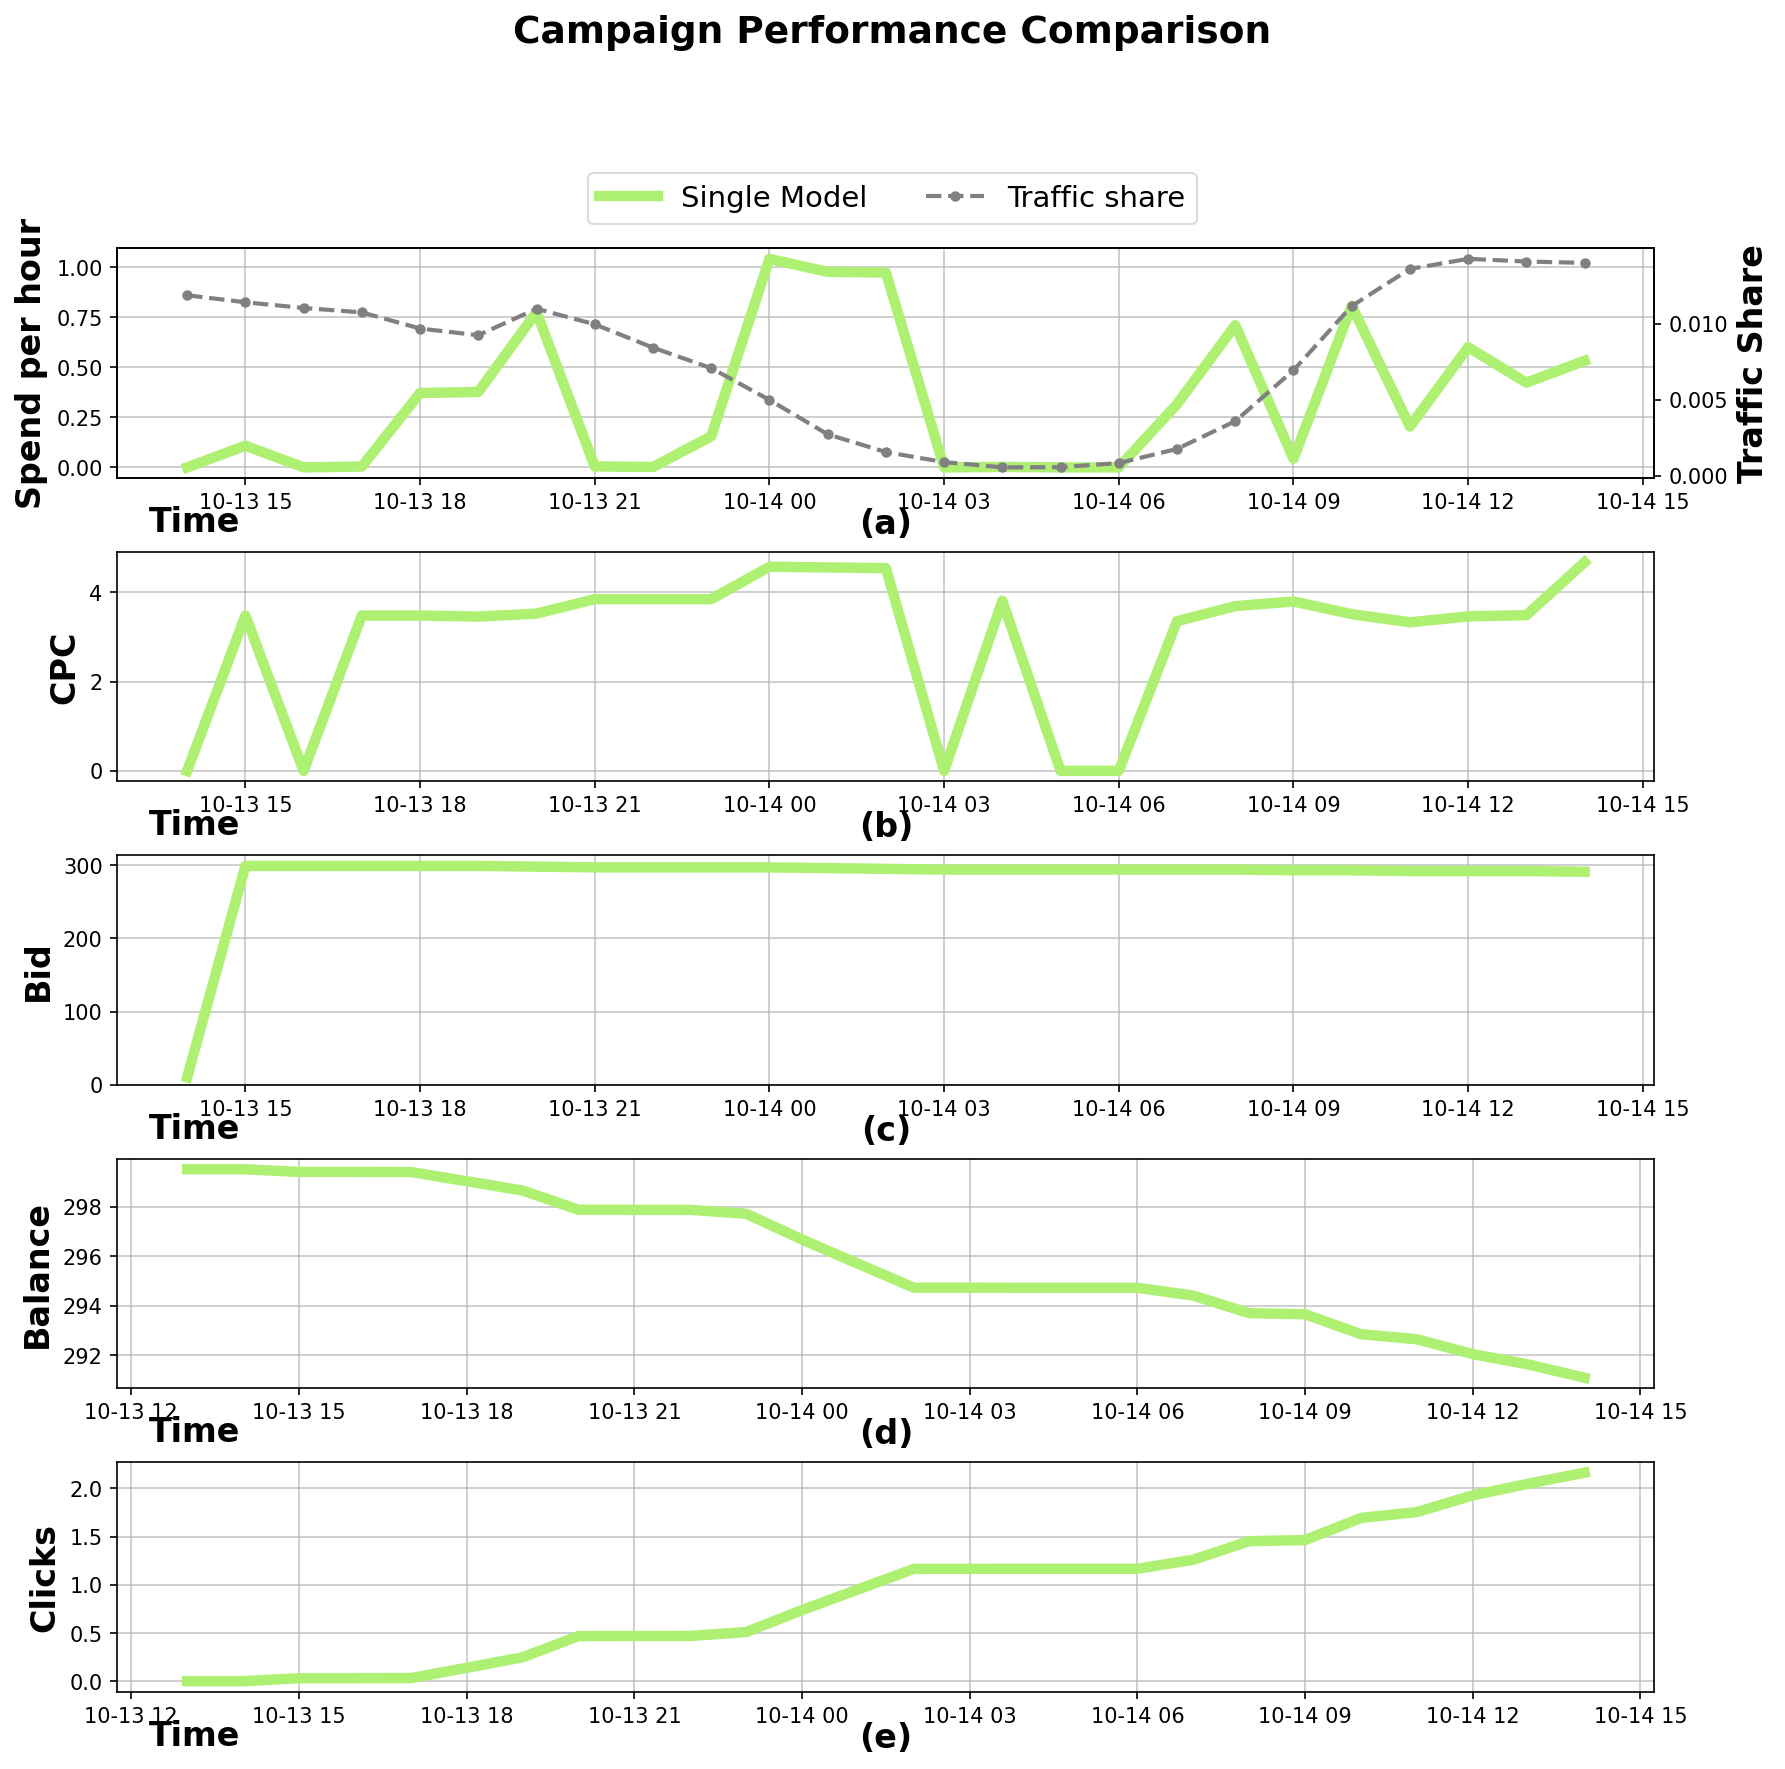

In [ ]:
# fig = plot_history_article(vis_data)